#### Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### Loading the dataset

In [2]:
data = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

#### Dataset Overview

In [3]:
data.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
print('Shape:', data.shape)
print('Number of columns:', len(data.columns))
print('Columns:')
print(data.columns.tolist())

Shape: (4000, 28)
Number of columns: 28
Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [6]:
data.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


#### Checking for missing values

In [7]:
data.isna().sum()

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [8]:
missing_summary = pd.DataFrame({'Missing Values': data.isnull().sum(), 'Missing Percentage': (data.isnull().sum() / len(data) * 100).round(2)})
missing_summary = missing_summary[missing_summary['Missing Values'] > 0]
missing_summary

,Missing Values,Missing Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [9]:
missing_cols = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']
data[missing_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Rainfall_mm,3952.0,601.152657,288.925025,80.0,370.20,582.00,834.95,1395.20
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.0,21.70,26.40,31.30,47.00
Yield_Tonnes_Ha,3968.0,5.270595,13.361398,0.3,1.05,1.74,2.84,101.44


In [10]:
for col in missing_cols:
    print(f"{col}")
    print("Mean   :", data[col].mean())
    print("Median :", data[col].median())
    print("Skewness:", data[col].skew())
    print()

Rainfall_mm
Mean   : 601.152656882591
Median : 582.0
Skewness: 0.13954270661227788

Soil_Moisture_pct
Mean   : 26.508232323232324
Median : 26.4
Skewness: -0.031709436431551934

Yield_Tonnes_Ha
Mean   : 5.270594758064516
Median : 1.74
Skewness: 4.039389373943371



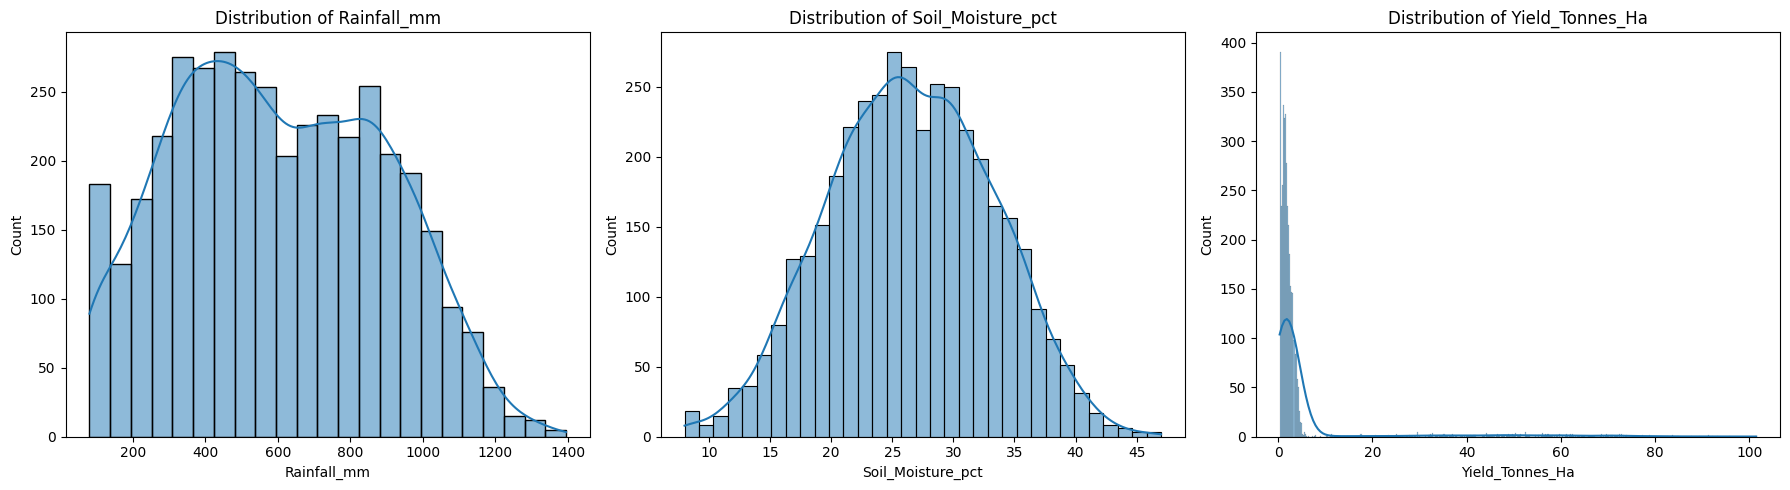

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, missing_cols):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

#### Handling missing values

In [12]:
data['Rainfall_mm'] = data['Rainfall_mm'].fillna(data['Rainfall_mm'].median())

data['Soil_Moisture_pct'] = data['Soil_Moisture_pct'].fillna(data['Soil_Moisture_pct'].mean())

data['Yield_Tonnes_Ha'] = data['Yield_Tonnes_Ha'].fillna(data['Yield_Tonnes_Ha'].median())

In [13]:
data.isnull().sum()

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64

#### **Categorical Variable - Univariate Analysis**

In [14]:
categorical_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']

categorical_summary = pd.DataFrame({
    'Unique Values': data[categorical_cols].nunique(),
    'Most Frequent Category': [data[col].mode()[0] for col in categorical_cols],
    'Frequency': [data[col].value_counts().iloc[0] for col in categorical_cols]
})

categorical_summary

,Unique Values,Most Frequent Category,Frequency
State,8,Andhra Pradesh,529
District,10,Ludhiana,427
Crop,8,Rice,690
Season,3,Kharif,1779
Irrigation_Method,4,Flood,1310


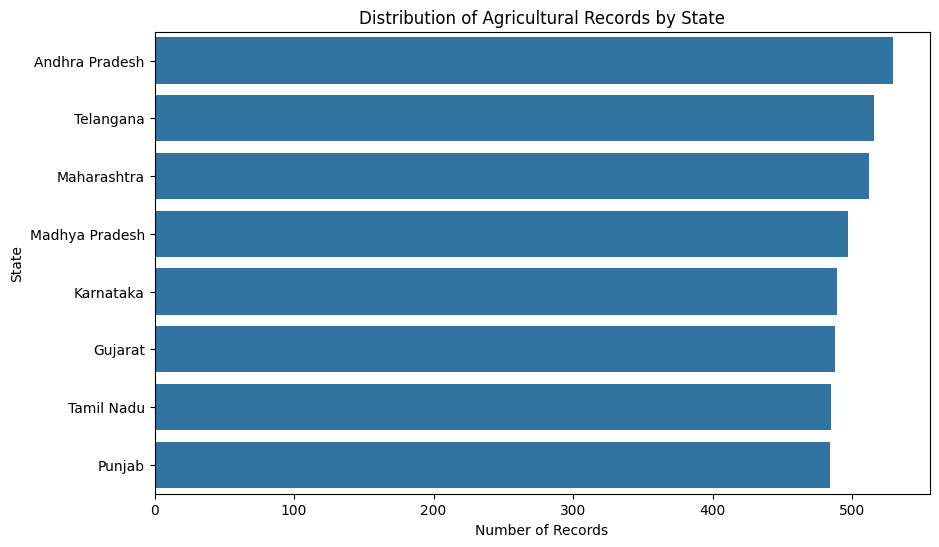

In [ ]:
plt.figure(figsize = (10,6))
sns.countplot(data = data, y = 'State', order = data['State'].value_counts().index)
plt.title('Distribution of Agricultural Records by State')
plt.xlabel('Number of Records')
plt.ylabel('State')
plt.show()

Agricultural records are fairly evenly distributed across the eight states, with Andhra Pradesh having the highest number of observations (529) and Punjab the lowest (484).

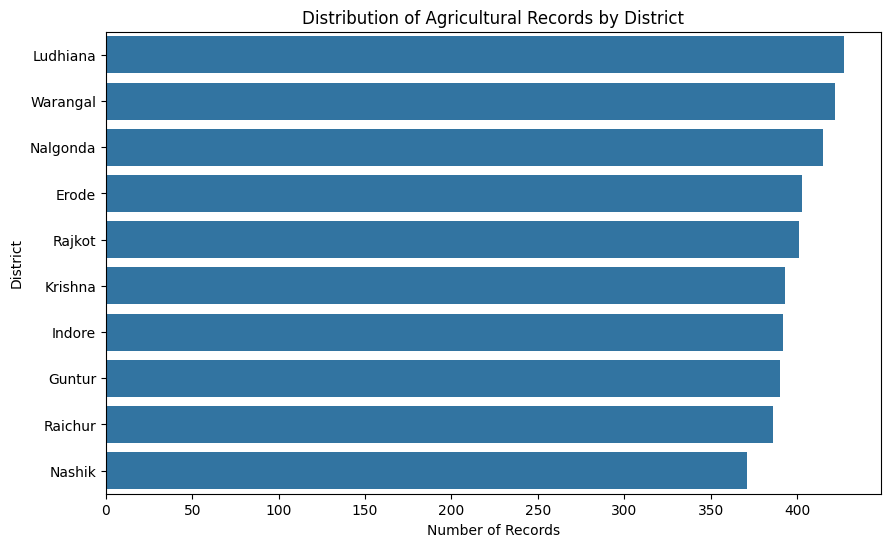

In [ ]:
plt.figure(figsize = (10,6))
sns.countplot(data = data, y = 'District', order = data['District'].value_counts().index)
plt.title('Distribution of Agricultural Records by District')
plt.xlabel('Number of Records')
plt.ylabel('District')
plt.show()

The dataset contains 10 districts with relatively even representation. Ludhiana has the highest number of observations (427), while Nashik has the lowest (371).

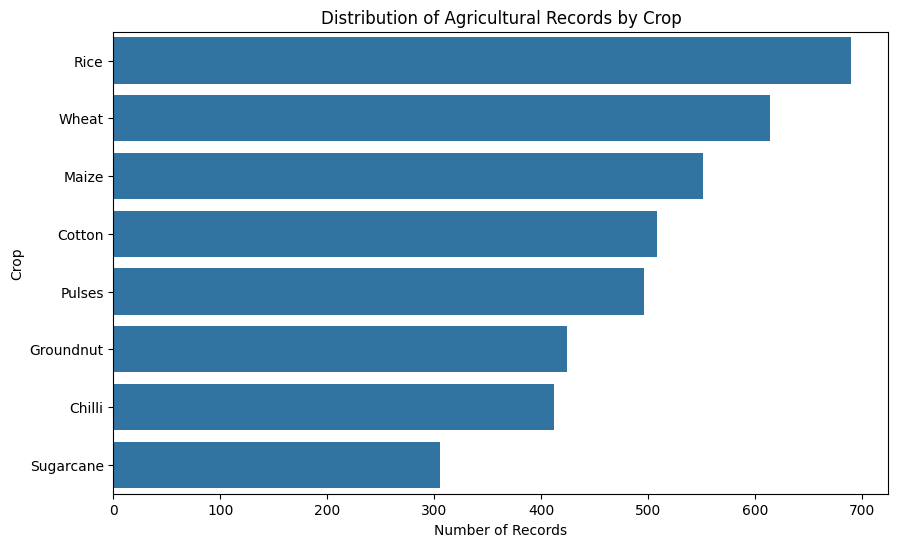

In [ ]:
plt.figure(figsize = (10,6))
sns.countplot(data = data, y = 'Crop', order = data['Crop'].value_counts().index)
plt.title('Distribution of Agricultural Records by Crop')
plt.xlabel('Number of Records')
plt.ylabel('Crop')
plt.show()

Rice is the most represented crop in the dataset, accounting for approximately 17% of observations, while Sugarcane has the lowest representation at approximately 8%.

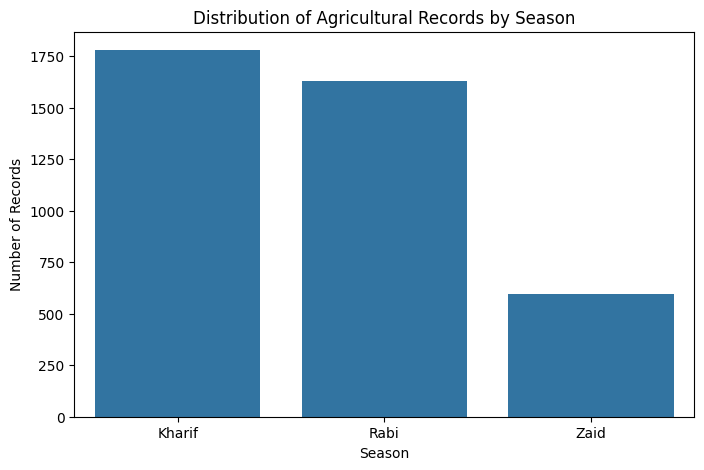

In [ ]:
plt.figure(figsize = (8,5))
sns.countplot(data = data, x = 'Season', order = data['Season'].value_counts().index)
plt.title('Distribution of Agricultural Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.show()

Kharif accounts for the largest share of observations (44.5%), followed by Rabi (40.7%), while Zaid represents a smaller 14.8% of the dataset.

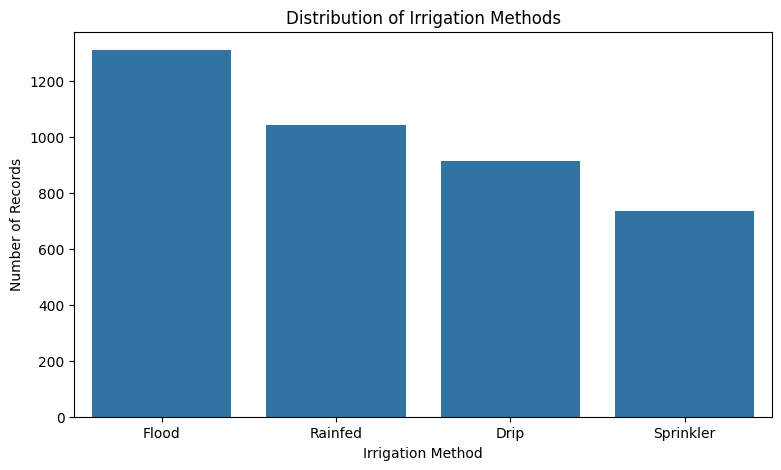

In [ ]:
plt.figure(figsize = (9,5))
sns.countplot(data = data, x = 'Irrigation_Method', order = data['Irrigation_Method'].value_counts().index)
plt.title('Distribution of Irrigation Methods')
plt.xlabel('Irrigation Method')
plt.ylabel('Number of Records')
plt.show()

Flood irrigation is the most common irrigation method (32.8%), while Sprinkler irrigation is the least represented (18.4%).

#### **Categorical Variables - Multivariate Analysis**

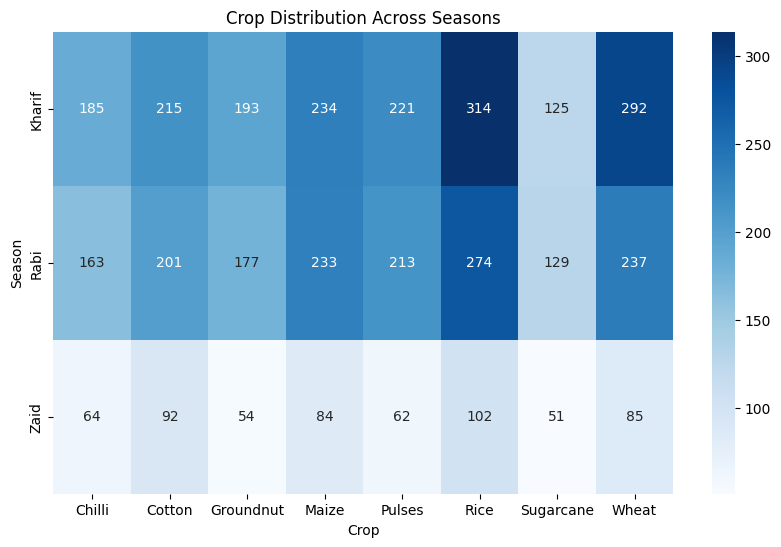

In [16]:
season_crop = pd.crosstab(data['Season'], data['Crop'])
plt.figure(figsize = (10, 6))
sns.heatmap(season_crop, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Crop Distribution Across Seasons')
plt.xlabel('Crop')
plt.ylabel('Season')
plt.show()

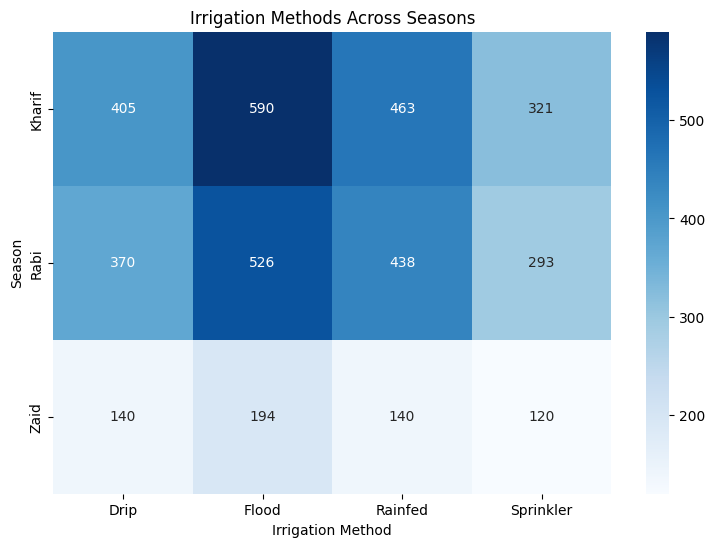

In [17]:
season_irrigation = pd.crosstab(data['Season'], data['Irrigation_Method'])
plt.figure(figsize = (9, 6))
sns.heatmap(season_irrigation, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Irrigation Methods Across Seasons')
plt.xlabel('Irrigation Method')
plt.ylabel('Season')
plt.show()

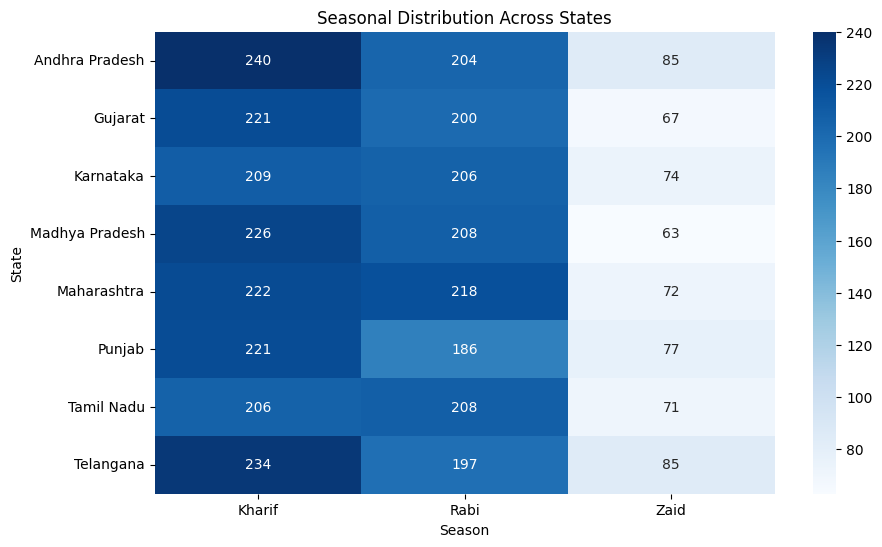

In [18]:
season_state = pd.crosstab(data['State'], data['Season'])
plt.figure(figsize = (10, 6))
sns.heatmap(season_state, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Seasonal Distribution Across States')
plt.xlabel('Season')
plt.ylabel('State')
plt.show()

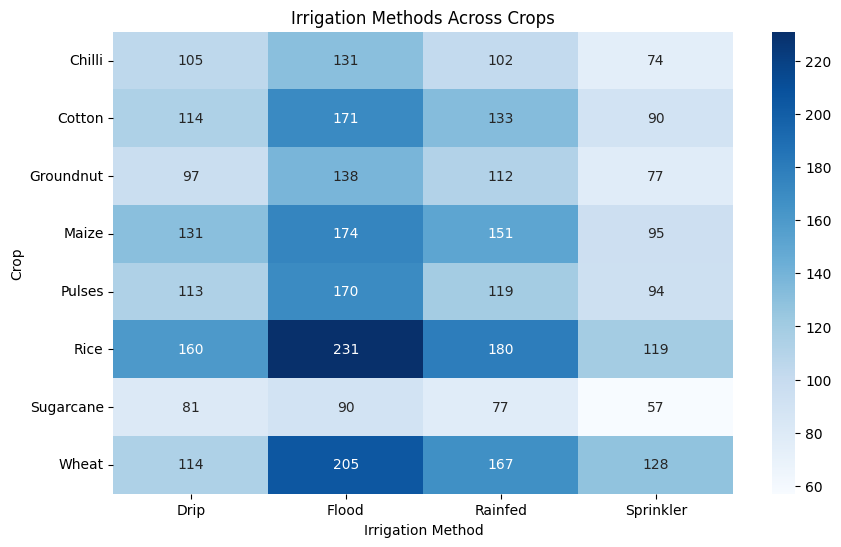

In [19]:
crop_irrigation = pd.crosstab(data['Crop'], data['Irrigation_Method'])
plt.figure(figsize = (10, 6))
sns.heatmap(crop_irrigation, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Irrigation Methods Across Crops')
plt.xlabel('Irrigation Method')
plt.ylabel('Crop')
plt.show()

#### Seasonal Yield Analysis

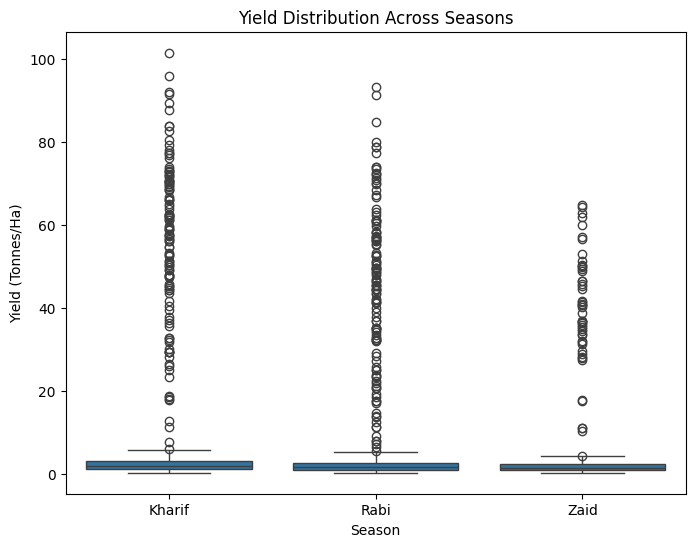

In [21]:
plt.figure(figsize = (8, 6))
sns.boxplot(data = data, x = 'Season', y = 'Yield_Tonnes_Ha')
plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [22]:
data.groupby('Season')['Yield_Tonnes_Ha'].agg(['count', 'mean', 'median', 'std']).round(2)

,count,mean,median,std
Season,,,,
Kharif,1779,5.63,1.94,14.39
Rabi,1627,5.04,1.67,12.75
Zaid,594,4.64,1.46,11.27


#### **Numerical Variable Analysis**

Numerical variables help us understand the environmental conditions, farming inputs, agricultural performance, resource usage and economic outcomes in the dataset.

The analysis focuses on the distribution and variation of important numerical variables before investigating their relationships with season and agricultural performance.

In [23]:
# Environmental conditions
environmental_vars = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct']

# Farming inputs
farming_input_vars = ['Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score']

# Agricultural performance
performance_vars = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']

# Economic performance
economic_vars = ['Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR']

#### Distribution of Environmental Conditions

Histograms are used to examine the distribution of rainfall, temperature, humidity, sunlight, soil pH and soil moisture. This helps identify the typical range of environmental conditions and whether any variables show strong skewness or unusual values.

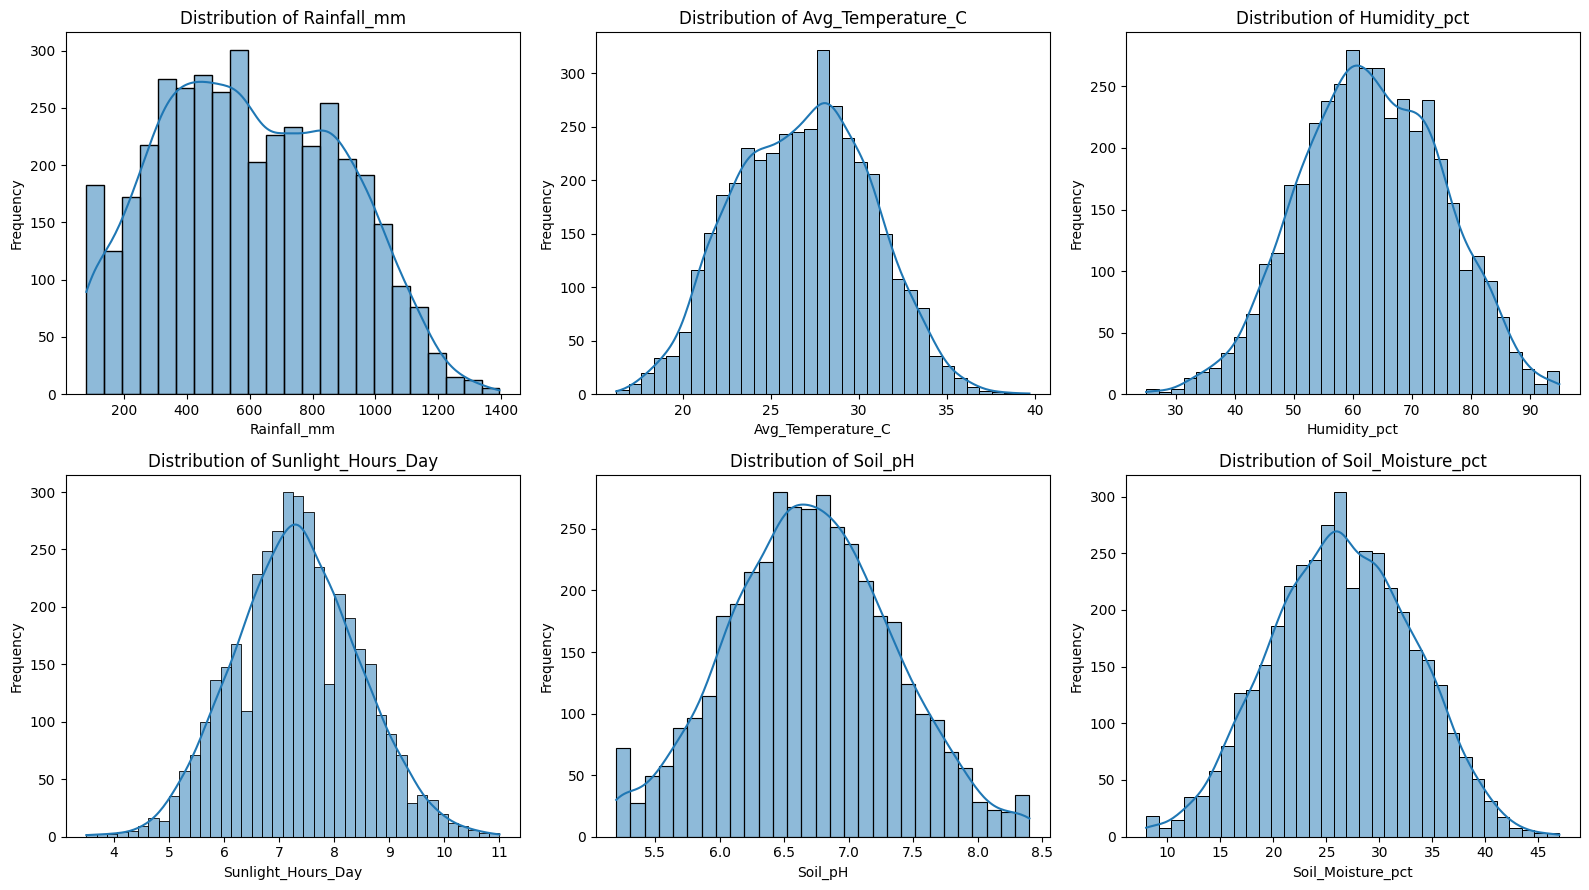

In [24]:
fig, axes = plt.subplots(2, 3, figsize = (16, 9))
for ax, col in zip(axes.flatten(), environmental_vars):
    sns.histplot(data[col], kde = True, ax = ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

The environmental variables show considerable variation across farms. Rainfall has a relatively wide range, while temperature, humidity, sunlight and soil conditions remain within more defined ranges. This indicates that farms in the dataset experience different environmental conditions, which can potentially contribute to differences in agricultural performance across seasons.

#### Distribution of Farming Inputs

The distributions of nitrogen, phosphorus, potassium, fertilizer, pesticide usage and seed quality are examined to understand how farming inputs vary across the dataset.

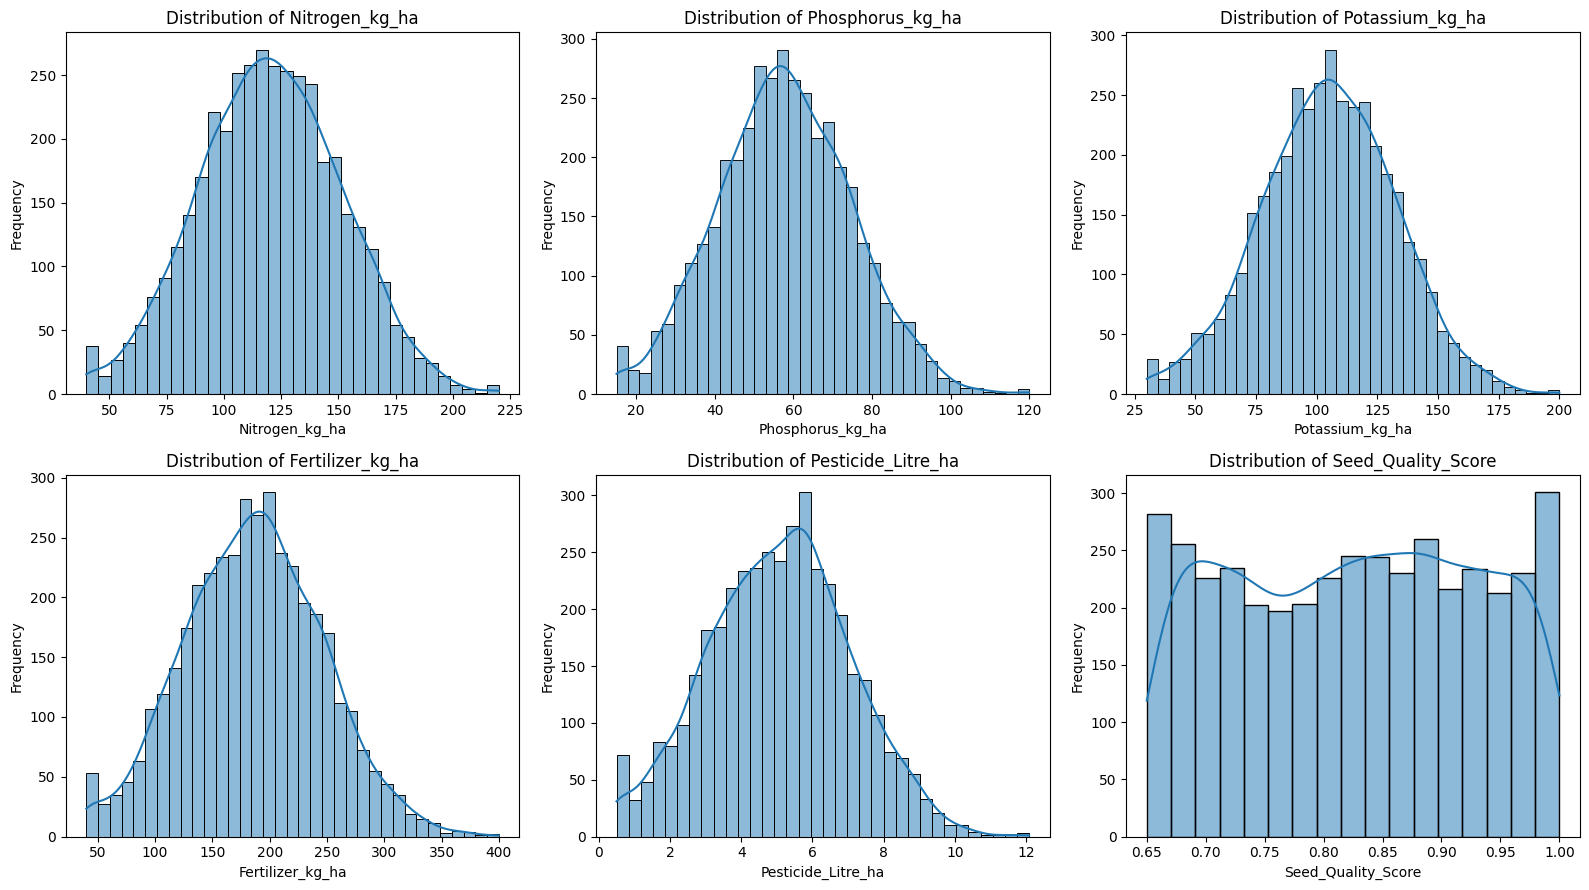

In [26]:
fig, axes = plt.subplots(2, 3, figsize = (16, 9))
for ax, col in zip(axes.flatten(), farming_input_vars):
    sns.histplot(data[col], kde = True, ax = ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Farming inputs vary considerably between farms, particularly nutrient and fertilizer application levels. Seed quality is comparatively concentrated within a narrower range. This variation provides an opportunity to examine whether differences in farming practices are associated with agricultural performance.

#### Distribution of Agricultural Performance

Agricultural performance variables are examined to understand the overall productivity and resource-use characteristics of the farms.

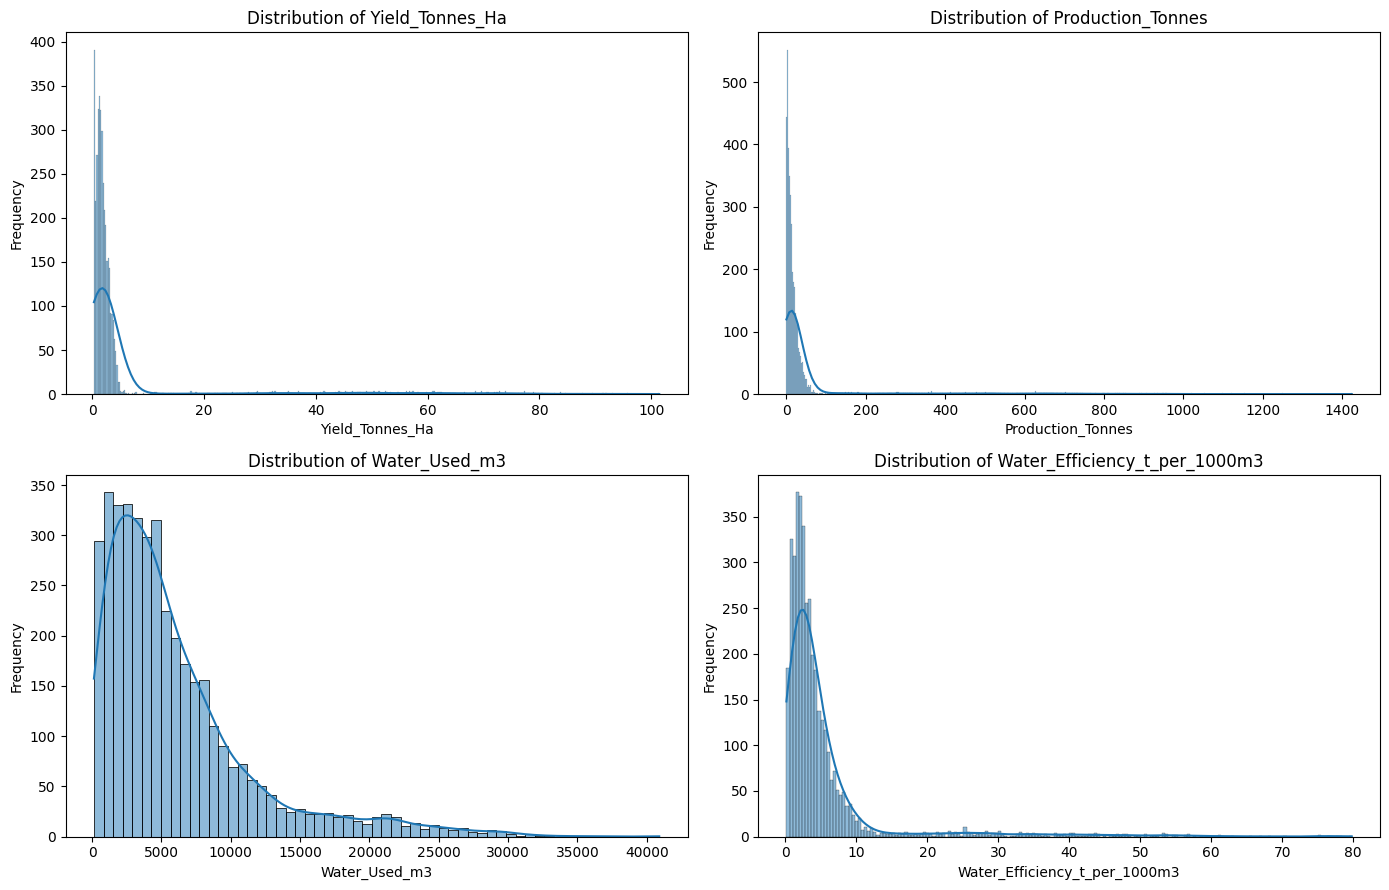

In [27]:
fig, axes = plt.subplots(2, 2, figsize = (14, 9))

for ax, col in zip(axes.flatten(), performance_vars):
    sns.histplot(data[col], kde = True, ax = ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Agricultural performance variables show substantial right-skewness. In particular, yield, production and water efficiency have means considerably higher than their medians, indicating that a relatively small number of farms have exceptionally high values. Therefore, median values and distribution-based visualizations are important when comparing agricultural performance.

#### Outlier Analysis of Agricultural Performance

Boxplots are used to identify the spread and potential extreme observations in agricultural performance variables.

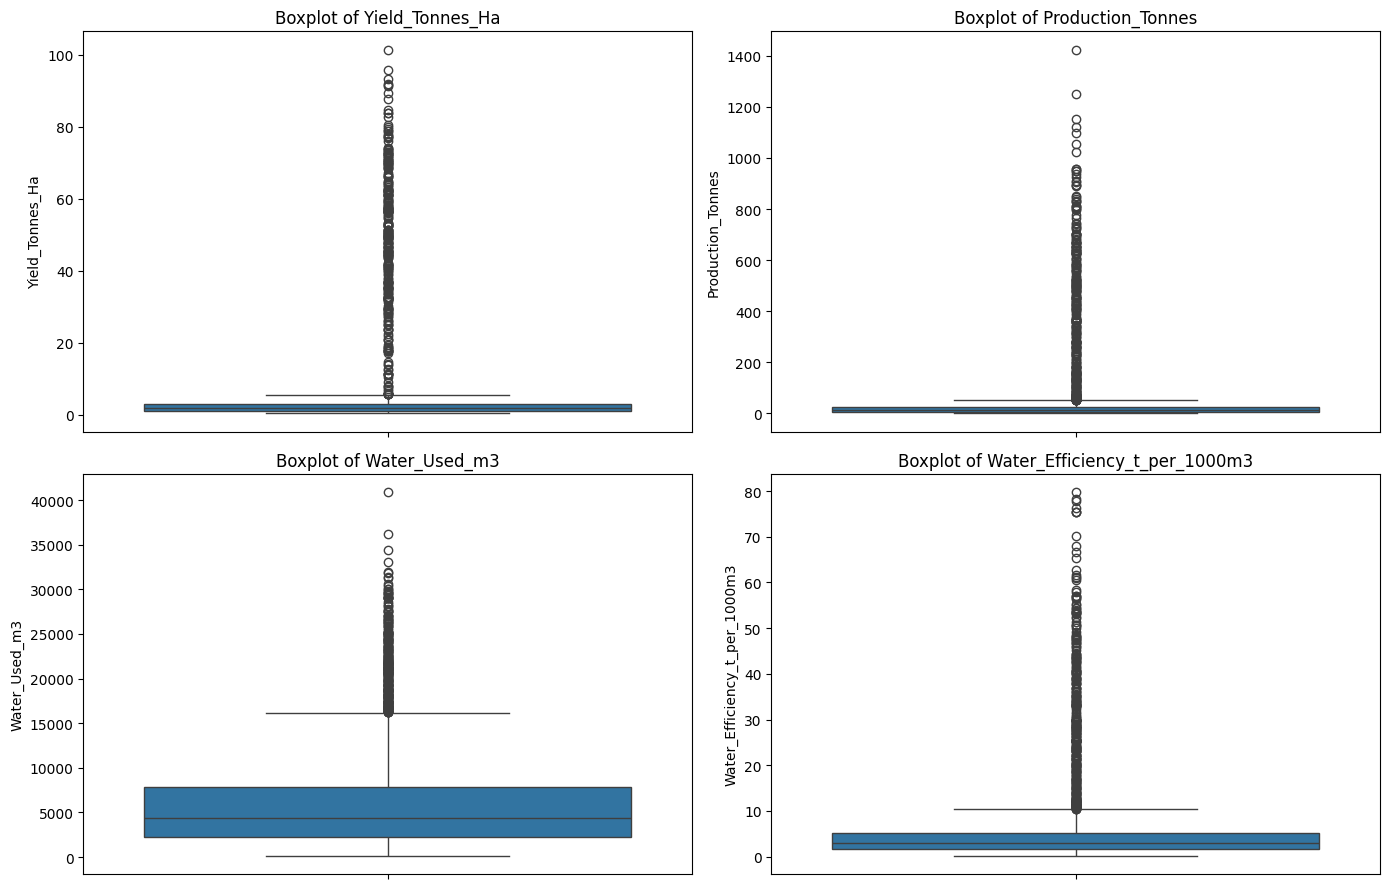

In [28]:
fig, axes = plt.subplots(2, 2, figsize = (14, 9))
for ax, col in zip(axes.flatten(), performance_vars):
    sns.boxplot(y = data[col], ax = ax)
    ax.set_title(f'Boxplot of {col}')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

The boxplots reveal substantial variation and several extreme high-value observations, particularly in yield, production and water efficiency. These observations contribute to the strong right-skewness observed earlier and should be considered when interpreting mean-based comparisons.

#### Distribution of Economic Performance

The economic variables are examined to understand the variation in market price, production costs, revenue and profit across farms.

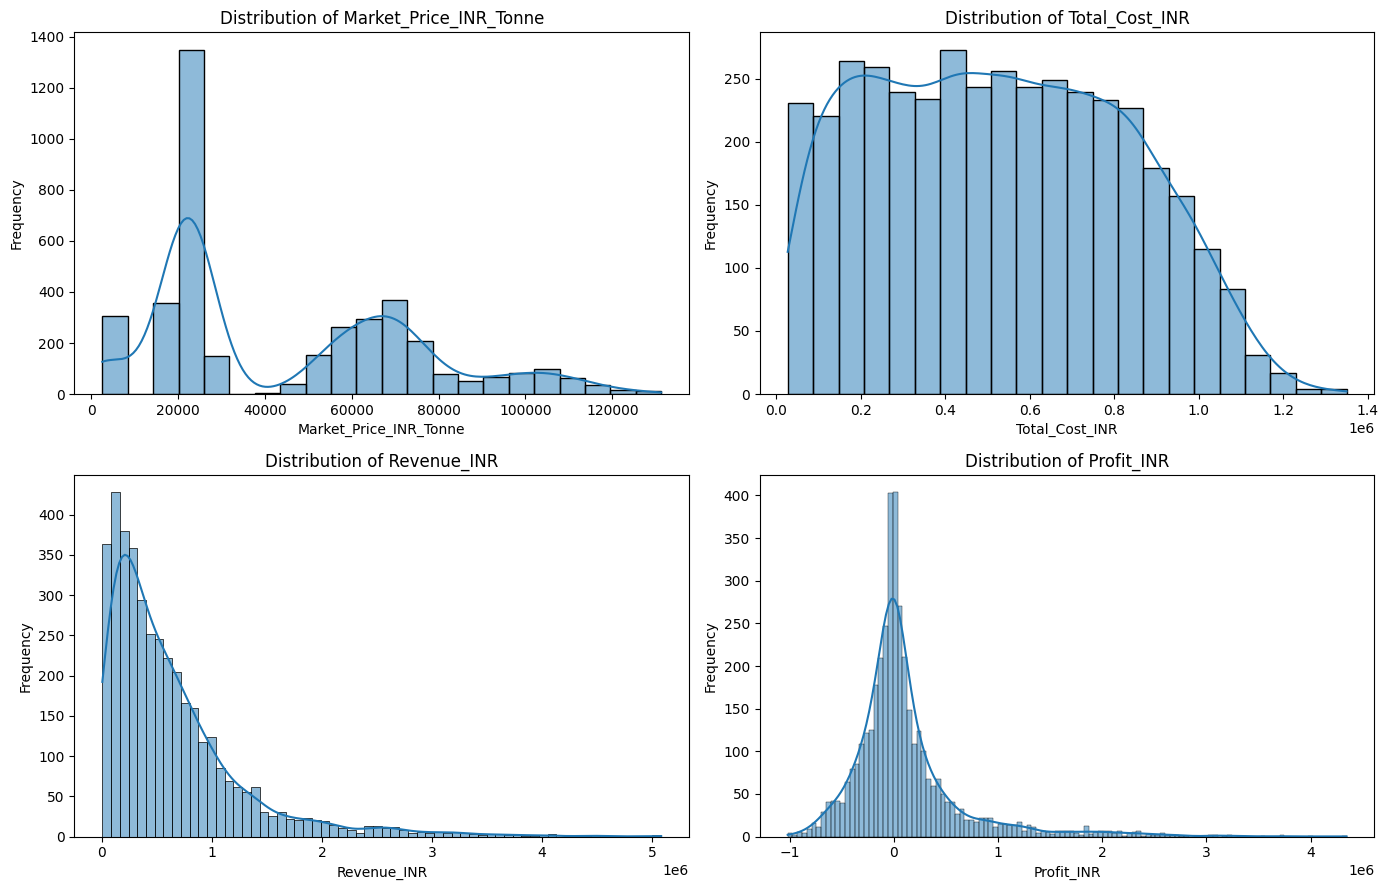

In [29]:
fig, axes = plt.subplots(2, 2, figsize = (14, 9))
for ax, col in zip(axes.flatten(), economic_vars):
    sns.histplot(data[col], kde = True, ax = ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

Economic performance varies substantially across farms. While some farms generate positive profits, the dataset also contains farms with significant losses. The wide variation in revenue, cost and profit suggests that agricultural performance cannot be evaluated using yield alone and that economic outcomes should be analyzed separately.

In [30]:
numerical_summary = data[environmental_vars + farming_input_vars + performance_vars + economic_vars].describe().T
numerical_summary = numerical_summary[['mean', '50%', 'std', 'min', 'max']]
numerical_summary.rename(columns = {'50%': 'median'}, inplace = True)
numerical_summary

,mean,median,std,min,max
Rainfall_mm,600.922825,582.0000,287.193381,80.000,1395.20
Avg_Temperature_C,26.818900,26.9000,3.818180,16.200,39.70
Humidity_pct,63.210500,63.0000,11.960834,25.000,95.00
Sunlight_Hours_Day,7.323050,7.3000,1.121186,3.500,11.00
Soil_pH,6.701010,6.6900,0.641461,5.200,8.40
Soil_Moisture_pct,26.508232,26.5000,6.678828,8.000,47.00
Nitrogen_kg_ha,120.250825,120.1000,31.216452,40.000,220.00
Phosphorus_kg_ha,57.781850,57.5000,17.015074,15.000,120.00
Potassium_kg_ha,104.760050,105.1000,27.742681,30.000,200.00
Fertilizer_kg_ha,186.036000,186.2500,60.260583,40.000,400.00


#### Seasonal Performance Analysis

Seasonal analysis examines how environmental conditions, agricultural productivity, resource efficiency and economic performance vary across Kharif, Rabi and Zaid seasons.

#### Average Rainfall by Season

In [31]:
rainfall_season = (data.groupby('Season')['Rainfall_mm'].agg(['mean', 'median']).round(2).sort_values('mean', ascending=False))
rainfall_season

,mean,median
Season,,
Kharif,849.20,853.1
Rabi,437.62,432.2
Zaid,304.65,288.2


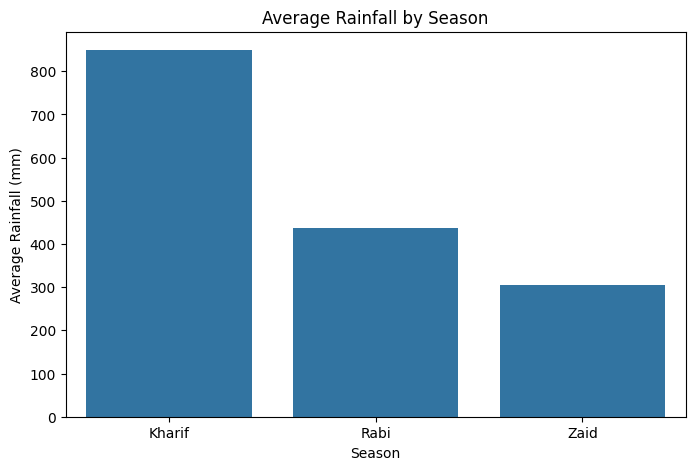

In [32]:
plt.figure(figsize = (8, 5))
season_rainfall = (data.groupby('Season')['Rainfall_mm'].mean().sort_values(ascending = False))
sns.barplot(x = season_rainfall.index, y = season_rainfall.values)
plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Average Rainfall (mm)')
plt.show()

#### Temperature Variation Across Seasons

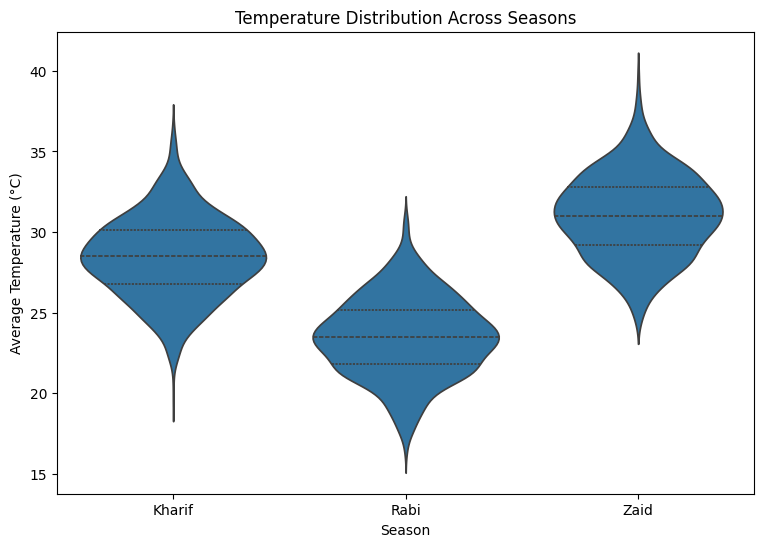

In [33]:
plt.figure(figsize = (9, 6))
sns.violinplot(data = data, x = 'Season', y = 'Avg_Temperature_C', inner = 'quartile')
plt.title('Temperature Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Temperature (°C)')
plt.show()

Temperature varies clearly across seasons. Zaid has the highest average temperature at 31.04°C, followed by Kharif at 28.45°C, while Rabi has the lowest at 23.49°C. The similar standard deviations indicate that temperature variability within each season is relatively consistent.

In [34]:
data.groupby('Season')['Avg_Temperature_C'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)

,mean,median,std,min,max
Season,,,,,
Kharif,28.45,28.5,2.51,19.4,36.8
Rabi,23.49,23.5,2.46,16.2,31.1
Zaid,31.04,31.0,2.55,24.5,39.7


#### Soil Moisture Across Seasons

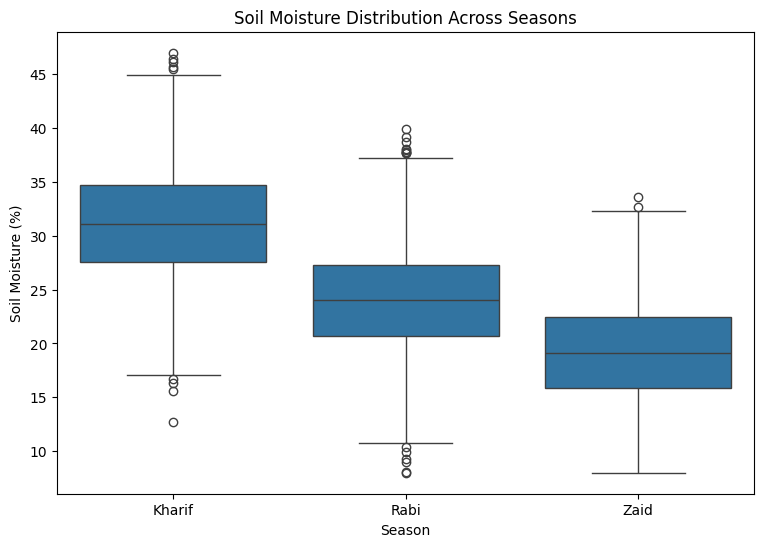

In [35]:
plt.figure(figsize=(9, 6))
sns.boxplot(data = data, x = 'Season', y = 'Soil_Moisture_pct')
plt.title('Soil Moisture Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Soil Moisture (%)')
plt.show()

Soil moisture shows a clear seasonal pattern. Kharif has the highest average soil moisture at 31.15%, followed by Rabi at 24.07%, while Zaid has the lowest at 19.28%. The relatively similar standard deviations indicate comparable within-season variability.

In [36]:
data.groupby('Season')['Soil_Moisture_pct'].agg(['mean', 'median', 'std']).round(2)

,mean,median,std
Season,,,
Kharif,31.15,31.1,5.04
Rabi,24.07,24.0,4.94
Zaid,19.28,19.1,4.94


#### Yield Across Seasons

In [37]:
season_yield = data.groupby('Season')['Yield_Tonnes_Ha'].agg(Count = 'count', Mean = 'mean', Median = 'median', Std = 'std', Min = 'min', Max = 'max').round(2)
season_yield

,Count,Mean,Median,Std,Min,Max
Season,,,,,,
Kharif,1779,5.63,1.94,14.39,0.3,101.44
Rabi,1627,5.04,1.67,12.75,0.3,93.13
Zaid,594,4.64,1.46,11.27,0.3,64.76


Kharif records the highest agricultural yield, with both the highest mean yield (5.63 tonnes/ha) and median yield (1.94 tonnes/ha). Rabi follows with a mean of 5.04 tonnes/ha, while Zaid has the lowest mean and median yields at 4.64 and 1.46 tonnes/ha respectively. This indicates that Kharif generally performs better in terms of yield, while Zaid records the lowest typical yield.

The large standard deviations relative to the median indicate substantial variation in yield within each season, suggesting that crop type and other farm-level factors may also play an important role.

#### Median Yield by Crop

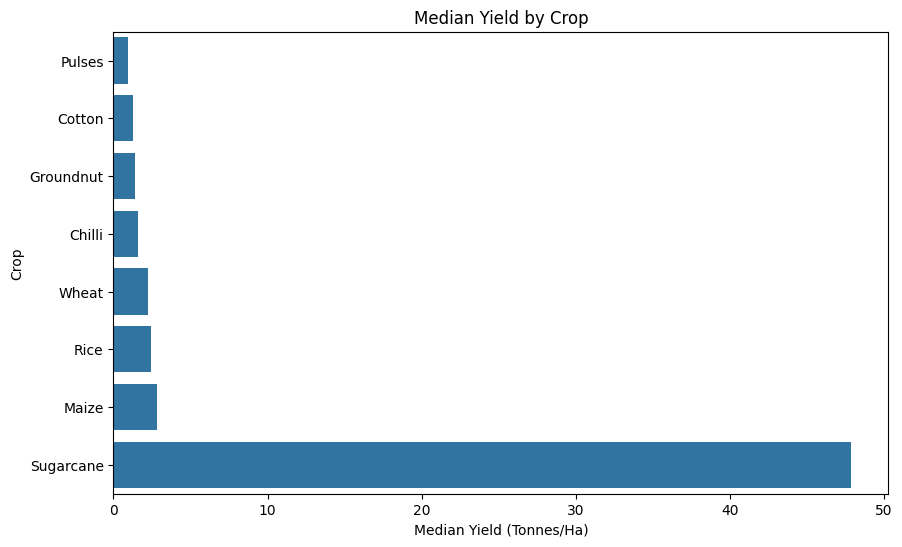

In [39]:
crop_yield = (data.groupby('Crop')['Yield_Tonnes_Ha'].median().sort_values(ascending = True))
plt.figure(figsize = (10, 6))
sns.barplot(x = crop_yield.values, y = crop_yield.index)
plt.title('Median Yield by Crop')
plt.xlabel('Median Yield (Tonnes/Ha)')
plt.ylabel('Crop')
plt.show()

Yield varies substantially across crops. Sugarcane has a dramatically higher median yield of 47.88 tonnes/ha, while the remaining crops have median yields below 3 tonnes/ha. Maize records the highest median yield among the remaining crops at 2.84 tonnes/ha, whereas Pulses has the lowest at 0.94 tonnes/ha.

In [40]:
data.groupby('Crop')['Yield_Tonnes_Ha'].agg(Mean = 'mean', Median = 'median', Count = 'count').round(2).sort_values('Median', ascending = False)

,Mean,Median,Count
Crop,,,
Sugarcane,46.64,47.88,305
Maize,2.71,2.84,551
Rice,2.43,2.44,690
Wheat,2.11,2.22,614
Chilli,1.54,1.56,412
Groundnut,1.32,1.40,424
Cotton,1.23,1.25,508
Pulses,0.92,0.94,496


The large difference in yield across crops highlights the importance of crop type when comparing seasonal agricultural performance. Therefore, seasonal comparisons should also consider crop composition rather than attributing all yield differences directly to season.

#### Crop Yield Performance Across Seasons

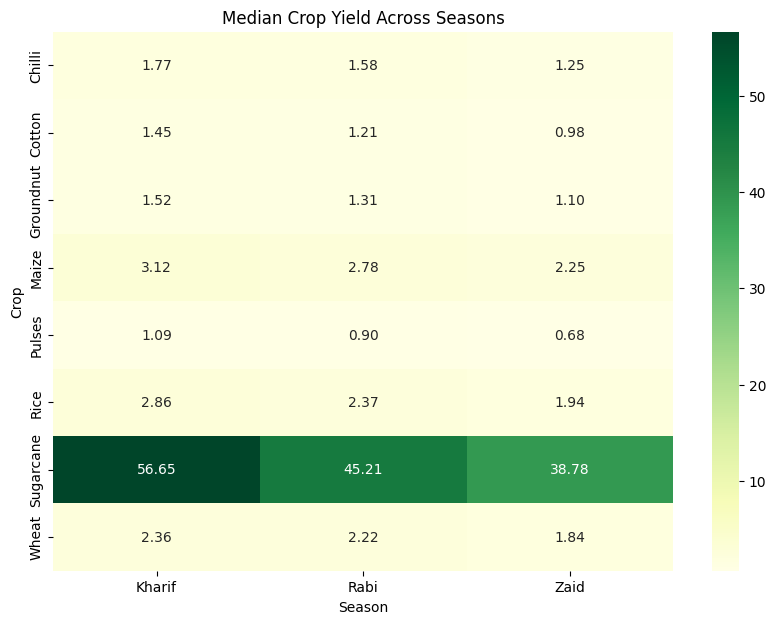

In [41]:
crop_season_yield = data.pivot_table(values = 'Yield_Tonnes_Ha', index = 'Crop', columns = 'Season', aggfunc = 'median')
plt.figure(figsize = (10, 7))
sns.heatmap(crop_season_yield, annot = True, fmt = '.2f', cmap = 'YlGn')
plt.title('Median Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.show()

Median yield is consistently higher during Kharif than Rabi and Zaid across all crops in the dataset. Sugarcane records the highest yield in every season, while Pulses generally records the lowest. The consistent seasonal pattern across crops suggests that seasonal conditions are associated with differences in crop productivity, although other factors such as irrigation, inputs and environmental conditions may also contribute.

#### Water-Use Efficiency Across Seasons

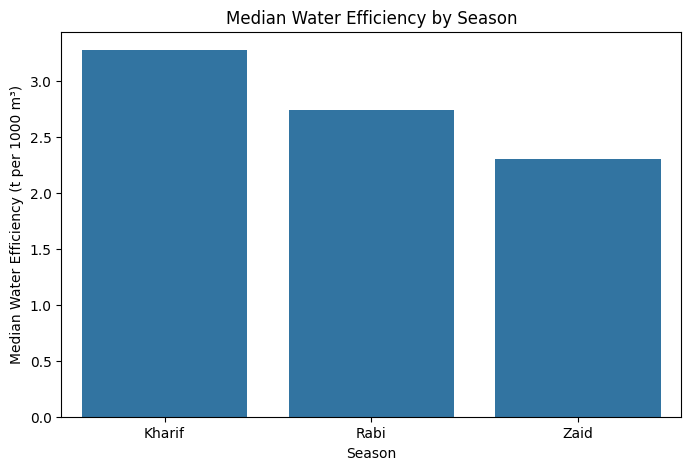

In [42]:
water_efficiency_season = (data.groupby('Season')['Water_Efficiency_t_per_1000m3'].median().sort_values(ascending=False))
plt.figure(figsize = (8, 5))
sns.barplot(x = water_efficiency_season.index, y = water_efficiency_season.values)
plt.title('Median Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Median Water Efficiency (t per 1000 m³)')
plt.show()

Kharif has the highest median water-use efficiency at 3.28 tonnes per 1,000 m³, followed by Rabi at 2.74 and Zaid at 2.30. This suggests that farms in Kharif achieve greater agricultural output per unit of water used compared with the other seasons.

In [43]:
data.groupby('Season')['Water_Efficiency_t_per_1000m3'].agg(Mean = 'mean', Median = 'median').round(2)

,Mean,Median
Season,,
Kharif,5.89,3.28
Rabi,5.19,2.74
Zaid,4.41,2.30


The difference between mean and median indicates that water efficiency is strongly influenced by a smaller number of highly efficient farms.

#### Profitability Across Seasons

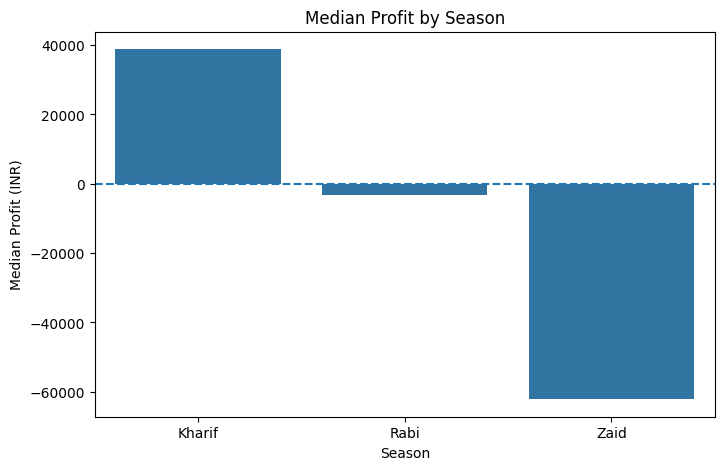

In [44]:
season_profit = (data.groupby('Season')['Profit_INR'].median().sort_values(ascending=False))
plt.figure(figsize = (8, 5))
sns.barplot(x = season_profit.index, y = season_profit.values)
plt.axhline(0, linestyle = '--')
plt.title('Median Profit by Season')
plt.xlabel('Season')
plt.ylabel('Median Profit (INR)')
plt.show()

Kharif demonstrates the strongest economic performance, with a positive median profit of ₹38,808. Rabi has a slightly negative median profit of −₹3,187, while Zaid records a substantially negative median profit of −₹62,144. The results indicate that revenue generated during Kharif is more effective at covering production costs, whereas Zaid faces the greatest profitability challenge.

In [45]:
data.groupby('Season')['Profit_INR'].agg(Mean = 'mean', Median = 'median', Min = 'min', Max = 'max').round(2)

,Mean,Median,Min,Max
Season,,,,
Kharif,178914.65,38808.0,-976860,4345421
Rabi,87689.47,-3187.0,-1019223,3378879
Zaid,-24804.82,-62144.0,-965197,2349990


The large difference between mean and median profit suggests that a relatively small number of highly profitable farms substantially increase the average profit, making the median a more representative measure of typical farm profitability.

#### Profitability Rate by Season

In [46]:
data['Profitable'] = data['Profit_INR'] > 0
profitability_rate = (data.groupby('Season')['Profitable'].mean().mul(100).round(2).sort_values(ascending=False))
profitability_rate

Season
Kharif    57.79
Rabi      48.86
Zaid      35.52
Name: Profitable, dtype: float64

Kharif has the highest proportion of profitable farms at 57.79%, followed by Rabi at 48.86%. Zaid has the lowest profitability rate at only 35.52%. Thus, the seasonal profitability pattern is consistent with the median-profit analysis, with Kharif showing the strongest economic performance and Zaid showing the weakest.

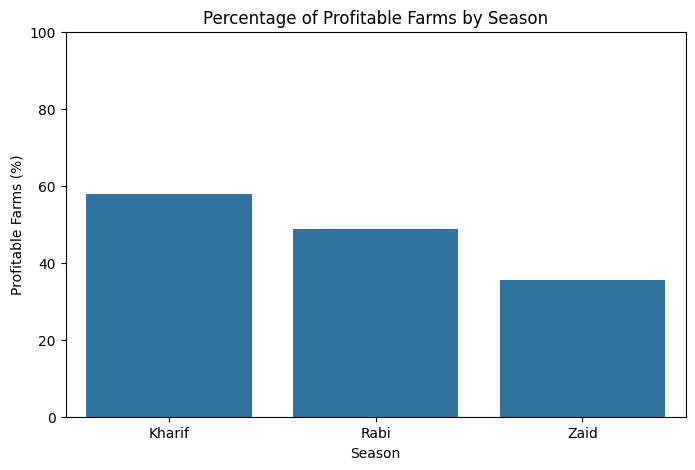

In [47]:
plt.figure(figsize = (8, 5))
sns.barplot(x = profitability_rate.index, y = profitability_rate.values)
plt.title('Percentage of Profitable Farms by Season')
plt.xlabel('Season')
plt.ylabel('Profitable Farms (%)')
plt.ylim(0, 100)
plt.show()

#### Seasonal Performance by State

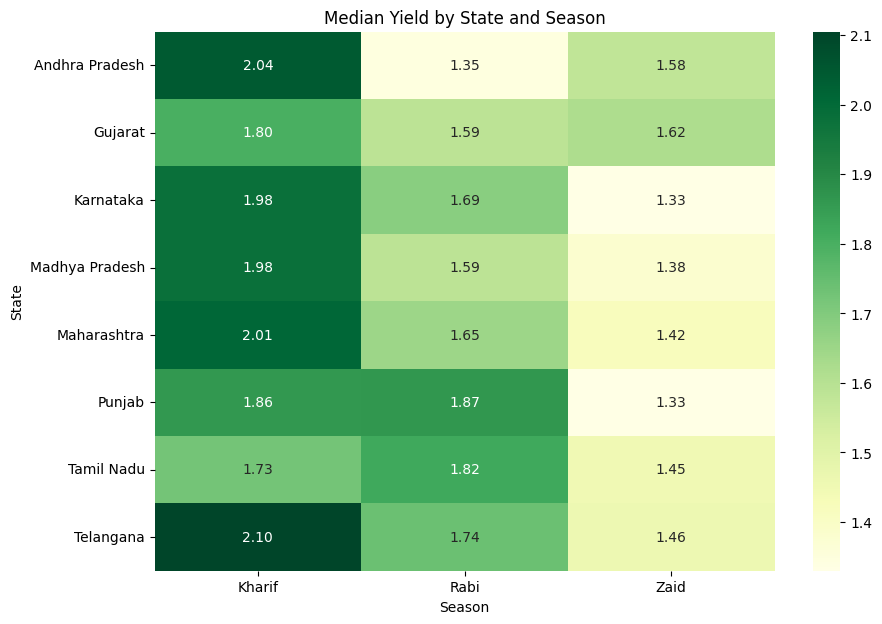

In [87]:
state_season_yield = data.pivot_table(values='Yield_Tonnes_Ha', index='State', columns='Season', aggfunc='median')
plt.figure(figsize=(10, 7))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='YlGn')
plt.title('Median Yield by State and Season')
plt.xlabel('Season')
plt.ylabel('State')
plt.show()

Seasonal yield patterns are broadly consistent across states, with Kharif recording the highest median yield in most regions. Telangana shows the highest Kharif median yield at 2.10 tonnes/ha, followed by Andhra Pradesh at 2.04 tonnes/ha. However, some regional variations are visible, such as Punjab, where Rabi yield slightly exceeds Kharif, and Gujarat, where Zaid performs slightly better than Rabi. This indicates that although season-level patterns are generally consistent, regional conditions can modify seasonal performance.

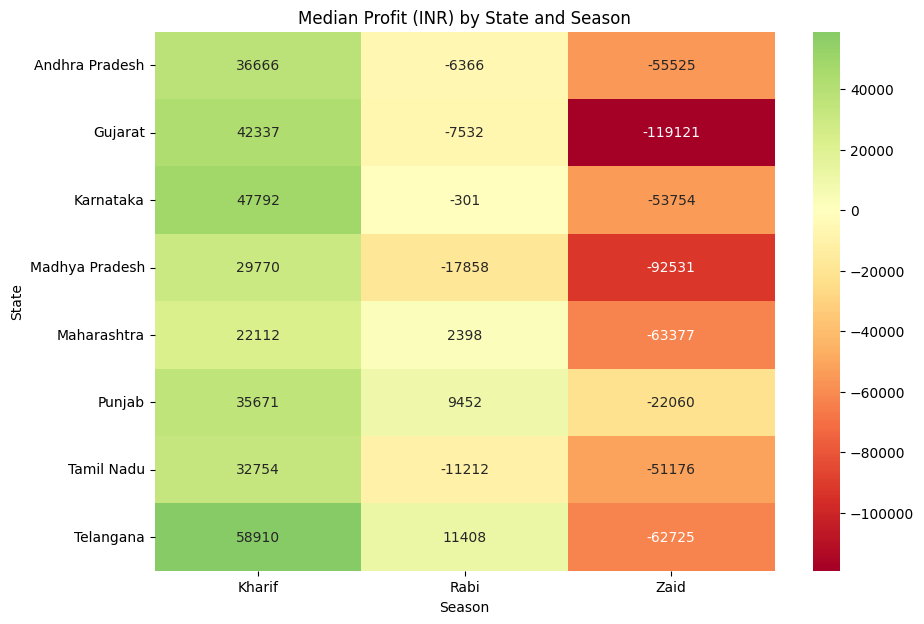

In [88]:
state_season_profit = data.pivot_table(values='Profit_INR', index='State', columns='Season', aggfunc='median')
plt.figure(figsize=(10, 7))
sns.heatmap(state_season_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Median Profit (INR) by State and Season')
plt.xlabel('Season')
plt.ylabel('State')
plt.show()

Profitability shows a stronger regional and seasonal variation than yield. All states record positive median profits during Kharif, whereas every state records negative median profits during Zaid. Rabi shows a mixed pattern, with Telangana and Punjab remaining profitable while most other states record losses. This indicates that the economic impact of seasonal conditions varies considerably across regions, even when yield differences are relatively small.

In [89]:
from scipy import stats

# Is Kharif's yield advantage over Zaid statistically real, or just descriptive?
kharif_yield = data.loc[data['Season']=='Kharif', 'Yield_Tonnes_Ha']
rabi_yield   = data.loc[data['Season']=='Rabi', 'Yield_Tonnes_Ha']
zaid_yield   = data.loc[data['Season']=='Zaid', 'Yield_Tonnes_Ha']

f_stat, p_val = stats.f_oneway(kharif_yield, rabi_yield, zaid_yield)
print(f"ANOVA — Yield across Seasons: F={f_stat:.2f}, p={p_val:.2e}",
      "-> significant" if p_val < 0.05 else "-> not significant")

# Same test for Profit, since yield differences don't guarantee profit differences
kharif_profit = data.loc[data['Season']=='Kharif', 'Profit_INR']
rabi_profit   = data.loc[data['Season']=='Rabi', 'Profit_INR']
zaid_profit   = data.loc[data['Season']=='Zaid', 'Profit_INR']

f_stat, p_val = stats.f_oneway(kharif_profit, rabi_profit, zaid_profit)
print(f"ANOVA — Profit across Seasons: F={f_stat:.2f}, p={p_val:.2e}",
      "-> significant" if p_val < 0.05 else "-> not significant")

# Pairwise: Kharif vs Zaid specifically (your most extreme comparison)
t_stat, p_val = stats.ttest_ind(kharif_yield, zaid_yield, equal_var=False)
print(f"Kharif vs Zaid Yield — t={t_stat:.2f}, p={p_val:.2e}",
      "-> significant" if p_val < 0.05 else "-> not significant")

t_stat, p_val = stats.ttest_ind(kharif_profit, zaid_profit, equal_var=False)
print(f"Kharif vs Zaid Profit — t={t_stat:.2f}, p={p_val:.2e}",
      "-> significant" if p_val < 0.05 else "-> not significant")

ANOVA — Yield across Seasons: F=1.54, p=2.14e-01 -> not significant
ANOVA — Profit across Seasons: F=34.29, p=1.71e-15 -> significant
Kharif vs Zaid Yield — t=1.72, p=8.61e-02 -> not significant
Kharif vs Zaid Profit — t=8.84, p=2.71e-18 -> significant


In [90]:
from scipy import stats

# Kruskal-Wallis: non-parametric alternative to ANOVA, robust to skew
h_stat, p_val = stats.kruskal(kharif_yield, rabi_yield, zaid_yield)
print(f"Kruskal-Wallis — Yield across Seasons: H={h_stat:.2f}, p={p_val:.2e}",
      "-> significant" if p_val < 0.05 else "-> not significant")

h_stat, p_val = stats.kruskal(kharif_profit, rabi_profit, zaid_profit)
print(f"Kruskal-Wallis — Profit across Seasons: H={h_stat:.2f}, p={p_val:.2e}",
      "-> significant" if p_val < 0.05 else "-> not significant")

Kruskal-Wallis — Yield across Seasons: H=68.71, p=1.20e-15 -> significant
Kruskal-Wallis — Profit across Seasons: H=101.93, p=7.36e-23 -> significant


The Kruskal-Wallis test indicates a statistically significant difference in profit distributions across seasons (H = 101.93, p < 0.001). This supports the descriptive analysis showing substantially stronger profitability during Kharif and weaker profitability during Zaid.

#### Environmental Factors and Agricultural Yield

After comparing agricultural performance across seasons, the next step is to investigate whether environmental conditions are associated with differences in crop yield.

#### Relationship Between Rainfall and Yield

Rainfall is examined to determine whether farms receiving different levels of rainfall tend to show differences in yield.

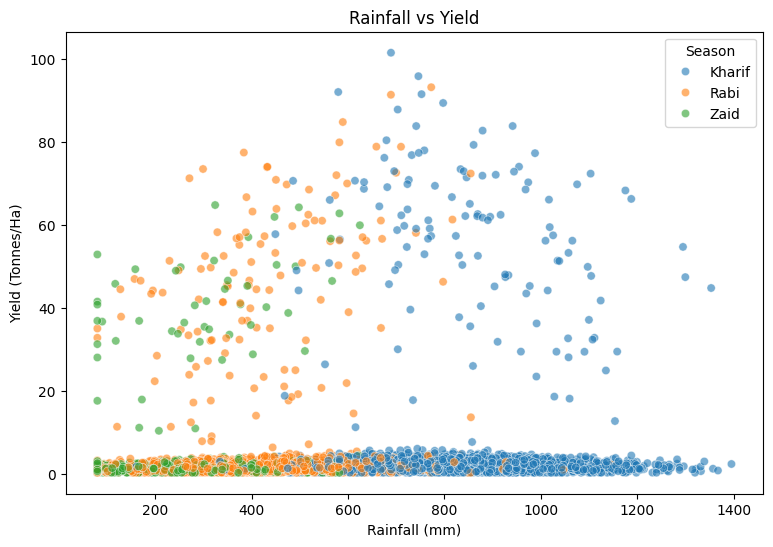

In [48]:
plt.figure(figsize = (9, 6))
sns.scatterplot(data = data, x = 'Rainfall_mm', y = 'Yield_Tonnes_Ha', hue = 'Season', alpha = 0.6)
plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [49]:
rainfall_yield_corr = data[['Rainfall_mm', 'Yield_Tonnes_Ha']].corr().iloc[0, 1]
print(f"Correlation between Rainfall and Yield: {rainfall_yield_corr:.3f}")

Correlation between Rainfall and Yield: 0.031


In [50]:
season_rainfall_corr = (data.groupby('Season').apply(lambda x: x['Rainfall_mm'].corr(x['Yield_Tonnes_Ha'])).round(3))
season_rainfall_corr

Season
Kharif   -0.015
Rabi      0.044
Zaid      0.052
dtype: float64

Rainfall shows almost no linear relationship with yield in the dataset, with an overall correlation of only 0.031. The seasonal correlations are also very weak (−0.015 for Kharif, 0.044 for Rabi and 0.052 for Zaid). Therefore, rainfall alone does not appear to be a strong predictor of yield in this dataset. The wide spread of yield values at similar rainfall levels suggests that other factors, such as crop type, soil conditions, farming inputs and irrigation, may have a greater influence on agricultural productivity.

#### Relationship Between Soil Moisture and Yield

Soil moisture varies considerably across seasons. This analysis examines whether differences in soil moisture are associated with differences in crop yield.

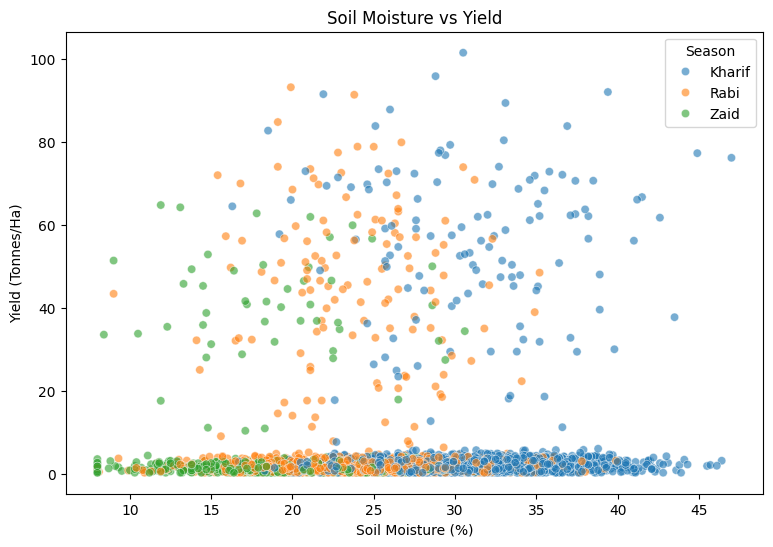

In [51]:
plt.figure(figsize = (9, 6))
sns.scatterplot(data = data, x = 'Soil_Moisture_pct', y = 'Yield_Tonnes_Ha', hue = 'Season', alpha = 0.6)
plt.title('Soil Moisture vs Yield')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [52]:
soil_moisture_yield_corr = data[['Soil_Moisture_pct', 'Yield_Tonnes_Ha']].corr().iloc[0, 1]
print(
    f"Correlation between Soil Moisture and Yield: "
    f"{soil_moisture_yield_corr:.3f}")

Correlation between Soil Moisture and Yield: 0.011


In [53]:
season_soil_corr = (data.groupby('Season').apply(lambda x: x['Soil_Moisture_pct'].corr(x['Yield_Tonnes_Ha'])).round(3))
season_soil_corr

Season
Kharif    0.001
Rabi     -0.017
Zaid     -0.031
dtype: float64

Soil moisture shows almost no linear relationship with yield, with an overall correlation of 0.011. The relationship remains negligible when examined separately by season, with correlations of 0.001 for Kharif, −0.017 for Rabi and 0.031 for Zaid. Although soil moisture differs substantially between seasons, these results indicate that soil moisture alone does not explain the variation in yield at the farm level. Other factors, including crop type, farming inputs and management practices, may have a greater influence on yield.

#### Relationship Between Seed Quality and Yield

Seed quality is examined to determine whether farms using higher-quality seeds tend to achieve higher crop yields.

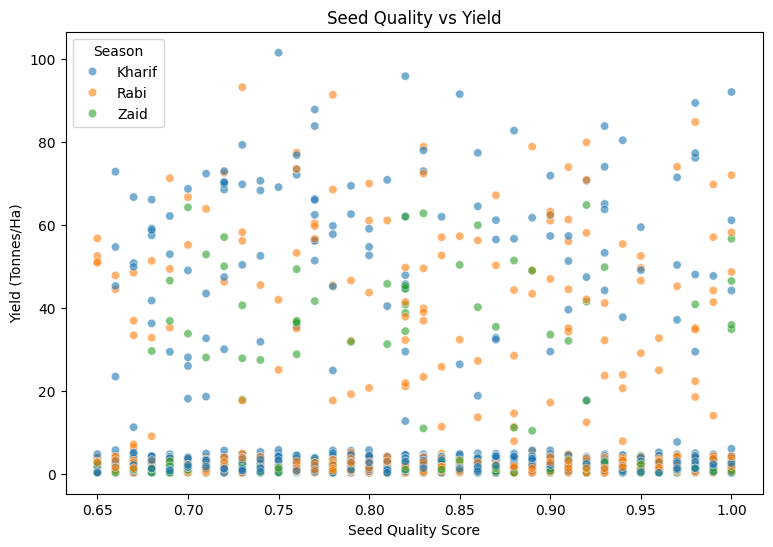

In [54]:
plt.figure(figsize = (9, 6))
sns.scatterplot(data = data, x = 'Seed_Quality_Score', y = 'Yield_Tonnes_Ha', hue = 'Season', alpha = 0.6)
plt.title('Seed Quality vs Yield')
plt.xlabel('Seed Quality Score')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [55]:
seed_yield_corr = data[['Seed_Quality_Score', 'Yield_Tonnes_Ha']].corr().iloc[0, 1]
print(
    f"Correlation between Seed Quality and Yield: "
    f"{seed_yield_corr:.3f}"
)

Correlation between Seed Quality and Yield: -0.007


In [56]:
season_seed_corr = (
    data.groupby('Season')
        .apply(
            lambda x: x['Seed_Quality_Score']
            .corr(x['Yield_Tonnes_Ha'])
        )
        .round(3)
)

season_seed_corr

Season
Kharif   -0.019
Rabi      0.007
Zaid     -0.001
dtype: float64

Seed quality shows virtually no linear relationship with yield, with an overall correlation of −0.007. The relationship remains negligible across Kharif (−0.019), Rabi (0.007) and Zaid (−0.004). The scatterplot also shows substantial variation in yield across similar seed-quality scores. Therefore, seed quality alone does not appear to be a strong factor explaining yield differences in this dataset.

#### Relationship Between Fertilizer Use and Yield

Fertilizer application is examined to determine whether fertilizer usage is associated with differences in crop yield.

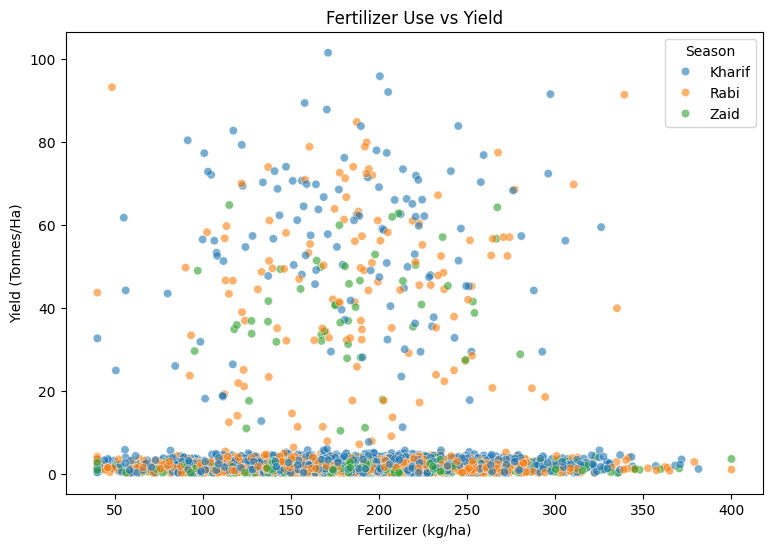

In [57]:
plt.figure(figsize = (9, 6))
sns.scatterplot(data = data, x = 'Fertilizer_kg_ha', y = 'Yield_Tonnes_Ha', hue = 'Season', alpha = 0.6)
plt.title('Fertilizer Use vs Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [58]:
fertilizer_yield_corr = data[['Fertilizer_kg_ha', 'Yield_Tonnes_Ha']].corr().iloc[0, 1]
print(
    f"Correlation between Fertilizer Use and Yield: "
    f"{fertilizer_yield_corr:.3f}"
)

Correlation between Fertilizer Use and Yield: 0.000


In [59]:
season_fertilizer_corr = (data.groupby('Season').apply(lambda x: x['Fertilizer_kg_ha'].corr(x['Yield_Tonnes_Ha'])).round(3))
season_fertilizer_corr

Season
Kharif   -0.014
Rabi      0.014
Zaid      0.007
dtype: float64

Fertilizer usage shows virtually no linear relationship with yield, with an overall correlation of 0.000. The seasonal correlations are also negligible, ranging from −0.014 to 0.014. The scatterplot shows substantial variation in yield at similar fertilizer application levels, indicating that fertilizer usage alone does not explain differences in agricultural productivity.

#### Correlation Analysis of Agricultural Variables

Correlation analysis is used to examine the strength and direction of linear relationships among environmental conditions, farming inputs, agricultural performance and economic variables.

The analysis helps identify variables that may be associated with agricultural yield and highlights relationships that require further investigation.

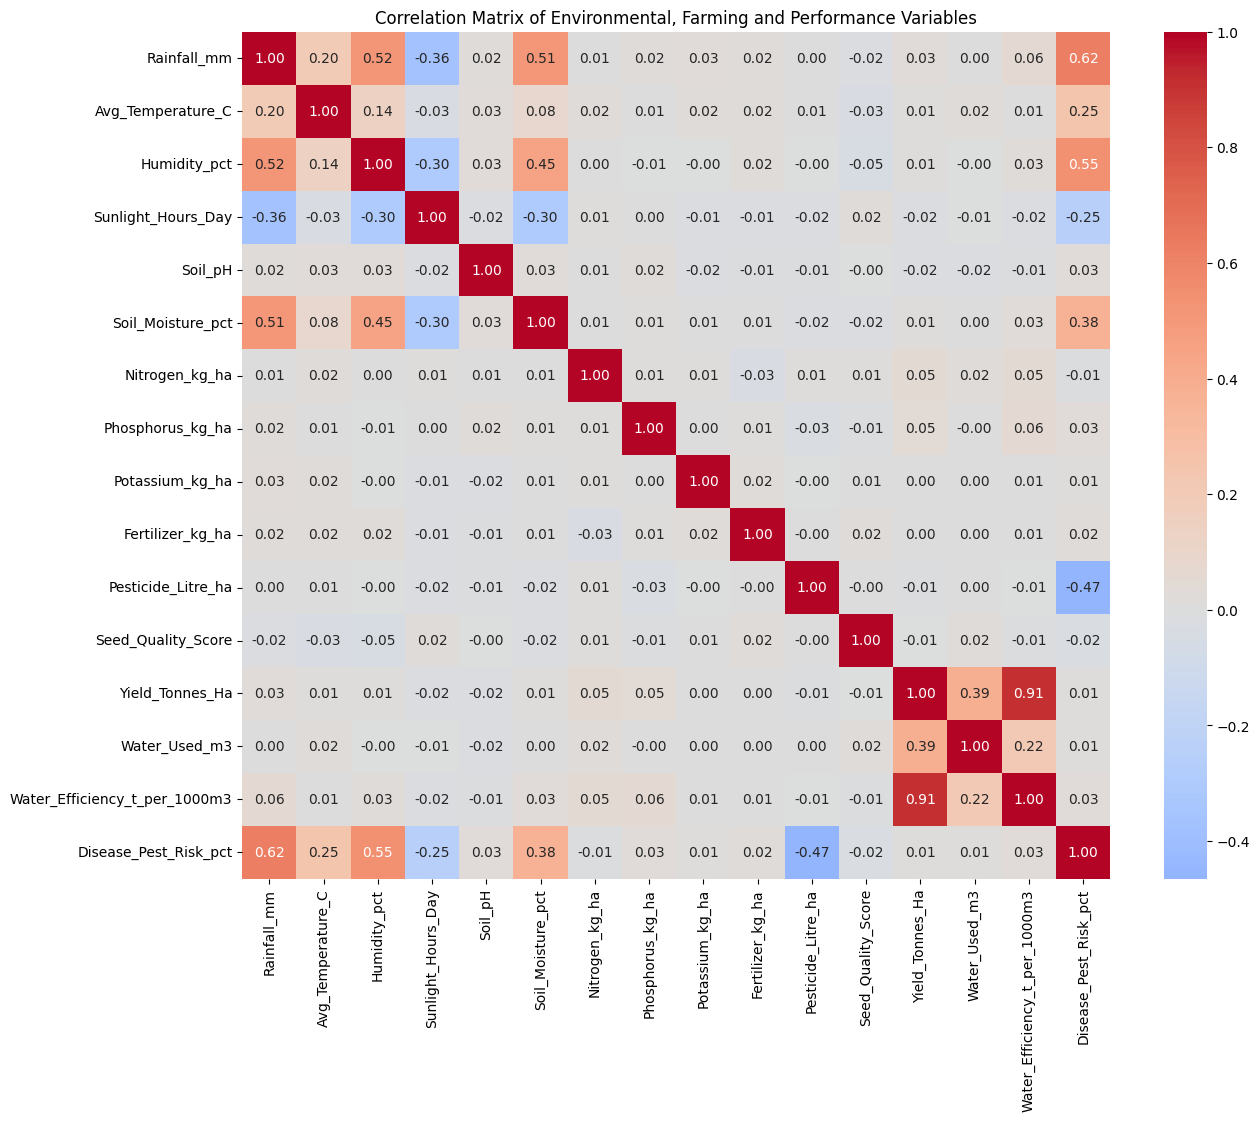

In [80]:
correlation_vars = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
corr_matrix = data[correlation_vars].corr()
plt.figure(figsize = (14, 11))
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0)
plt.title('Correlation Matrix of Environmental, Farming and Performance Variables')
plt.show()

In [61]:
yield_correlations = (
    corr_matrix['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
    .sort_values(ascending=False)
)

yield_correlations

Water_Efficiency_t_per_1000m3    0.912568
Water_Used_m3                    0.386294
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.011024
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0.015341
Soil_pH                         -0.020672
Name: Yield_Tonnes_Ha, dtype: float64

The correlation analysis shows that most individual environmental conditions and farming inputs have very weak linear relationships with yield. Rainfall, soil moisture, seed quality, fertilizer usage and other input variables show correlations close to zero with yield.

Water efficiency shows a strong positive correlation with yield; however, this variable is a derived agricultural performance measure that is mathematically related to production and water usage. Therefore, its strong correlation with yield should not be interpreted as evidence of an independent causal relationship.

Overall, the results suggest that yield variation is not adequately explained by any single environmental or farming-input variable. Crop type, season, irrigation practices and combinations of multiple factors may provide more meaningful explanations of agricultural performance.

#### Irrigation Practices and Agricultural Performance

Irrigation is an important agricultural management factor because it determines how water is supplied to crops. This analysis examines whether yield differs across irrigation methods.

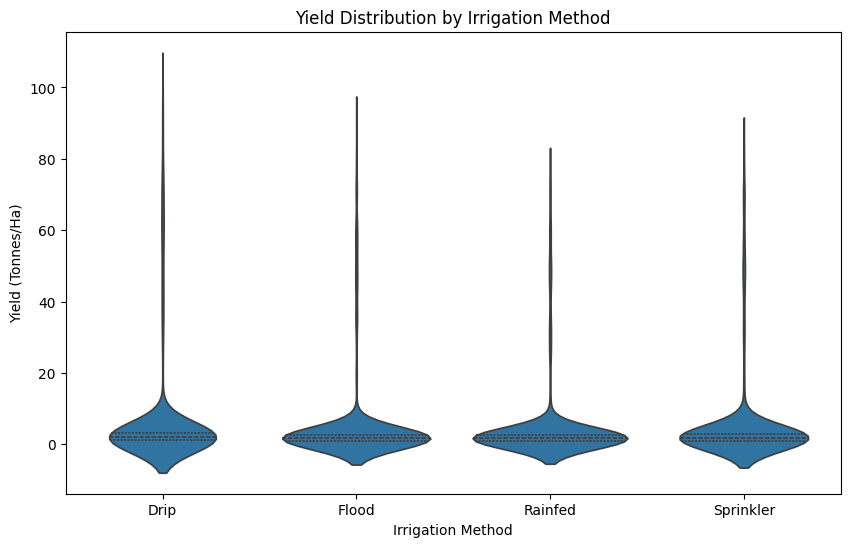

In [62]:
plt.figure(figsize = (10, 6))
sns.violinplot(data = data, x = 'Irrigation_Method', y = 'Yield_Tonnes_Ha', inner = 'quartile')
plt.title('Yield Distribution by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [63]:
irrigation_yield = (data.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].agg(Count = 'count', Mean = 'mean', Median = 'median', Std = 'std').round(2).sort_values('Median', ascending = False))
irrigation_yield

,Count,Mean,Median,Std
Irrigation_Method,,,,
Drip,915,6.58,1.94,16.20
Sprinkler,734,5.16,1.78,12.81
Rainfed,1041,4.60,1.72,11.56
Flood,1310,4.86,1.66,12.59


In [64]:
irrigation_season_yield = data.pivot_table(values = 'Yield_Tonnes_Ha', index = 'Irrigation_Method', columns = 'Season', aggfunc = 'median')
irrigation_season_yield.round(2)

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,2.14,1.82,1.52
Flood,1.88,1.60,1.25
Rainfed,1.86,1.60,1.46
Sprinkler,1.88,1.68,1.76


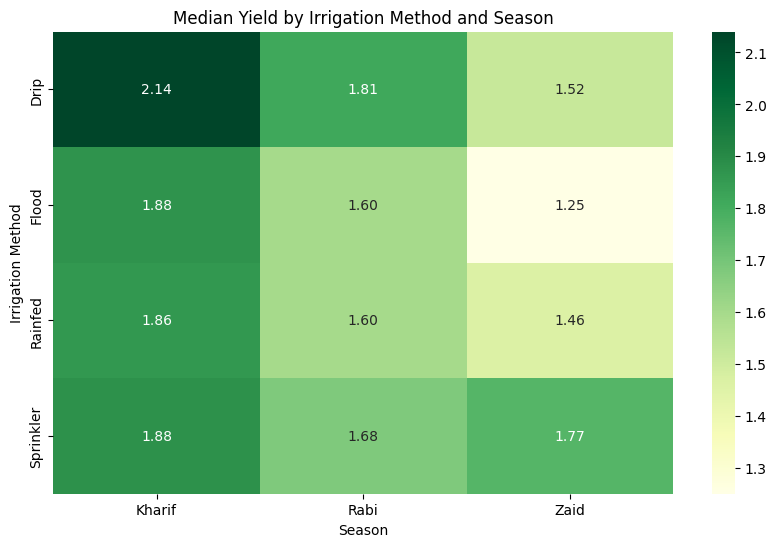

In [65]:
plt.figure(figsize = (10, 6))
sns.heatmap(irrigation_season_yield, annot = True, fmt = '.2f', cmap = 'YlGn')
plt.title('Median Yield by Irrigation Method and Season')
plt.xlabel('Season')
plt.ylabel('Irrigation Method')
plt.show()

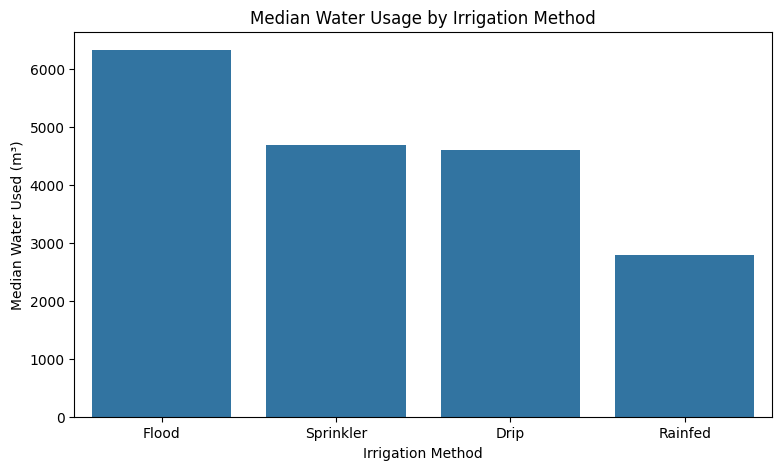

In [66]:
water_irrigation = (data.groupby('Irrigation_Method')['Water_Used_m3'].median().sort_values(ascending = False))
plt.figure(figsize = (9, 5))
sns.barplot(x = water_irrigation.index, y = water_irrigation.values)
plt.title('Median Water Usage by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Median Water Used (m³)')
plt.show()

In [67]:
data.groupby('Irrigation_Method')['Water_Used_m3'].agg(Mean = 'mean', Median = 'median').round(2)

,Mean,Median
Irrigation_Method,,
Drip,5918.75,4606.0
Flood,8026.47,6326.0
Rainfed,3549.55,2782.0
Sprinkler,6208.26,4687.0


Water usage varies substantially across irrigation methods. Flood irrigation has the highest median water consumption at 6,326 m³, followed by sprinkler irrigation at 4,687 m³ and drip irrigation at 4,606 m³. Rainfed farms have the lowest median water usage at 2,782 m³. This indicates that irrigation method is strongly associated with differences in water consumption, with flood irrigation requiring considerably more water than the other methods.

#### Water-Use Efficiency by Irrigation Method

Water-use efficiency is compared across irrigation methods to determine whether differences in water consumption are accompanied by differences in resource efficiency.

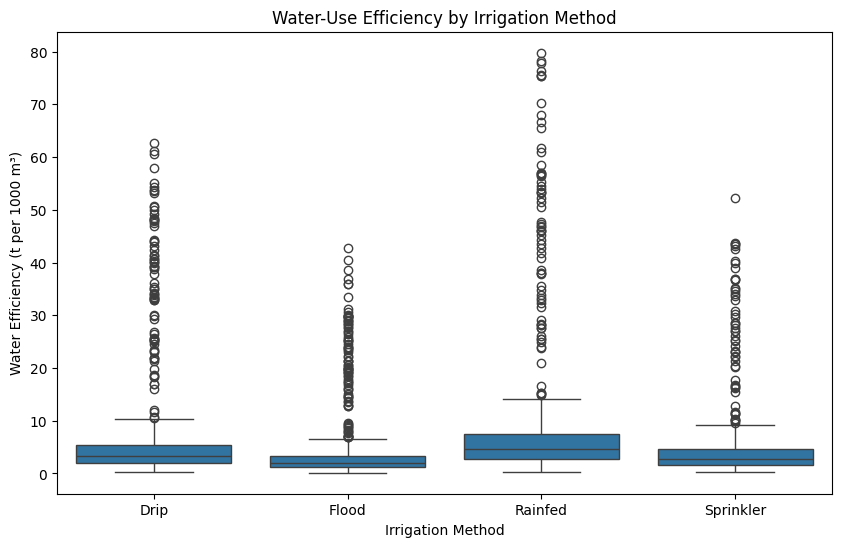

In [68]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = data, x = 'Irrigation_Method', y = 'Water_Efficiency_t_per_1000m3')
plt.title('Water-Use Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (t per 1000 m³)')
plt.show()

In [69]:
irrigation_efficiency = (
    data.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].agg(Count = 'count', Mean = 'mean', Median = 'median', Std = 'std').round(2).sort_values('Median', ascending = False))
irrigation_efficiency

,Count,Mean,Median,Std
Irrigation_Method,,,,
Rainfed,1041,7.56,4.58,11.34
Drip,915,6.27,3.26,10.02
Sprinkler,734,4.67,2.65,7.08
Flood,1310,3.44,1.95,5.47


In [70]:
irrigation_resource_summary = (data.groupby('Irrigation_Method').agg(Median_Water_Used = ('Water_Used_m3', 'median'), Median_Water_Efficiency = ('Water_Efficiency_t_per_1000m3', 'median'), Median_Yield = ('Yield_Tonnes_Ha', 'median')).round(2).sort_values('Median_Water_Efficiency', ascending = False))
irrigation_resource_summary

,Median_Water_Used,Median_Water_Efficiency,Median_Yield
Irrigation_Method,,,
Rainfed,2782.0,4.58,1.72
Drip,4606.0,3.26,1.94
Sprinkler,4687.0,2.65,1.78
Flood,6326.0,1.95,1.66


Irrigation methods show clear differences in both water consumption and resource efficiency. Flood irrigation has the highest median water usage (6,326 m³) and the lowest median water efficiency (1.95 t per 1,000 m³), while Rainfed farming has the lowest water usage (2,782 m³) and highest water efficiency (4.58 t per 1,000 m³). Drip irrigation records the highest median yield (1.94 t/ha) while using substantially less water than Flood irrigation. This suggests that Drip irrigation provides a comparatively favorable balance between agricultural productivity and water use in this dataset.

#### Irrigation Performance Across Seasons

The interaction between irrigation method and season is examined to determine whether irrigation performance varies under different seasonal conditions.

In [71]:
irrigation_season_summary = data.pivot_table(values = 'Yield_Tonnes_Ha', index = 'Irrigation_Method', columns = 'Season', aggfunc = 'median')
irrigation_season_summary.round(2)

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,2.14,1.82,1.52
Flood,1.88,1.60,1.25
Rainfed,1.86,1.60,1.46
Sprinkler,1.88,1.68,1.76


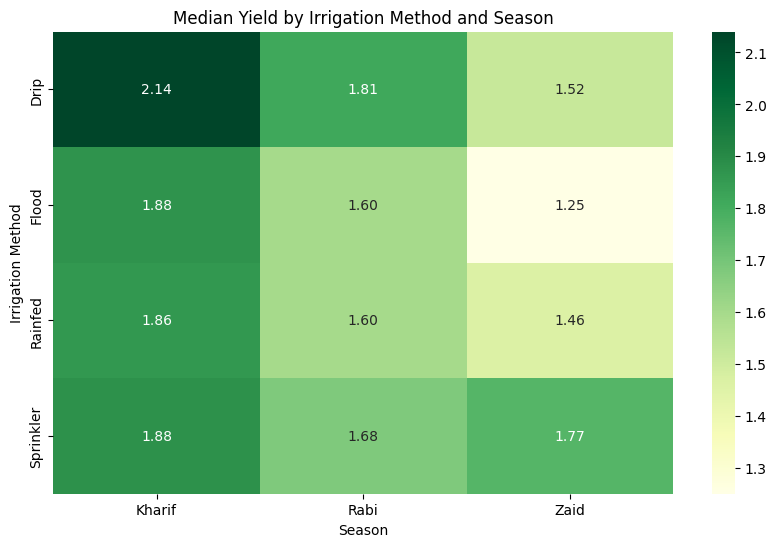

In [72]:
plt.figure(figsize = (10, 6))
sns.heatmap(irrigation_season_summary, annot = True, fmt = '.2f', cmap = 'YlGn')
plt.title('Median Yield by Irrigation Method and Season')
plt.xlabel('Season')
plt.ylabel('Irrigation Method')
plt.show()

#### Disease and Pest Risk Analysis

Disease and pest risk can affect agricultural productivity. This analysis examines whether farms with higher reported disease and pest risk tend to have different yield levels.

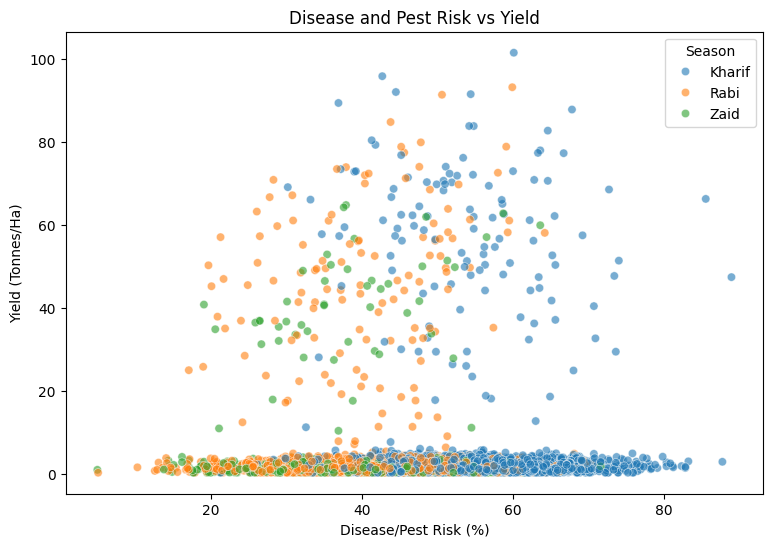

In [73]:
plt.figure(figsize = (9, 6))
sns.scatterplot(data = data, x = 'Disease_Pest_Risk_pct', y = 'Yield_Tonnes_Ha', hue = 'Season', alpha = 0.6)
plt.title('Disease and Pest Risk vs Yield')
plt.xlabel('Disease/Pest Risk (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

In [74]:
disease_yield_corr = data[['Disease_Pest_Risk_pct', 'Yield_Tonnes_Ha']].corr().iloc[0, 1]
print(
    f"Correlation between Disease/Pest Risk and Yield: "
    f"{disease_yield_corr:.3f}"
)

Correlation between Disease/Pest Risk and Yield: 0.014


Median yield varies across both irrigation methods and seasons. Kharif records the highest median yield for all irrigation methods, with Drip irrigation achieving the highest value at 2.14 tonnes/ha. In Rabi, Drip also records the highest median yield at 1.81 tonnes/ha, while in Zaid, Sprinkler irrigation performs best at 1.77 tonnes/ha. This indicates that the relationship between irrigation method and yield may differ depending on the season.

In [75]:
season_disease_corr = (data.groupby('Season').apply(lambda x: x['Disease_Pest_Risk_pct'].corr(x['Yield_Tonnes_Ha'])).round(3))
season_disease_corr

Season
Kharif   -0.027
Rabi      0.016
Zaid      0.040
dtype: float64

Disease and pest risk shows virtually no linear relationship with yield, with an overall correlation of 0.014. The relationship remains negligible across Kharif (0.027), Rabi (0.016) and Zaid (0.040). The scatterplot shows substantial variation in yield across similar risk levels, suggesting that disease and pest risk alone does not explain yield differences in this dataset.

#### Economic Performance Analysis

Agricultural performance is not determined by yield alone. Economic outcomes such as revenue, production cost and profit are also important for evaluating the overall performance of different seasons.

#### Revenue Across Seasons

Revenue is compared across seasons to determine whether differences in agricultural output and market returns are reflected in the income generated by farms.

In [76]:
season_revenue = (data.groupby('Season')['Revenue_INR'].agg(['mean', 'median']).round(2))
season_revenue

,mean,median
Season,,
Kharif,710719.06,520196.0
Rabi,601526.05,438156.0
Zaid,519171.90,373700.5


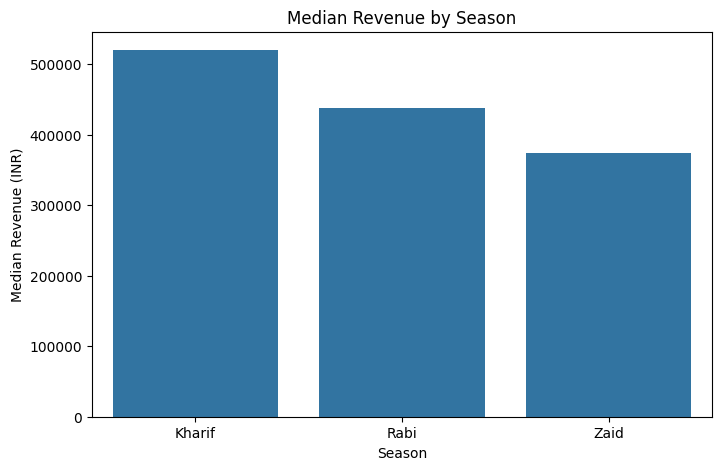

In [77]:
plt.figure(figsize = (8, 5))
revenue_median = (data.groupby('Season')['Revenue_INR'].median().sort_values(ascending=False))
sns.barplot(x = revenue_median.index, y = revenue_median.values)
plt.title('Median Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Median Revenue (INR)')
plt.show()

Kharif generates the highest median revenue at ₹520,196, followed by Rabi at ₹438,156 and Zaid at ₹373,700.50. This indicates that the seasonal differences observed in agricultural productivity are also reflected in farm revenue, with Kharif showing the strongest revenue performance.

#### Cost of Agricultural Production Across Seasons

Production costs are compared across seasons to determine whether higher revenue is accompanied by higher expenditure.

In [78]:
season_cost = (data.groupby('Season')['Total_Cost_INR'].agg(['mean', 'median']).round(2))
season_cost

,mean,median
Season,,
Kharif,531804.41,524840.0
Rabi,513836.58,506733.0
Zaid,543976.73,534833.0


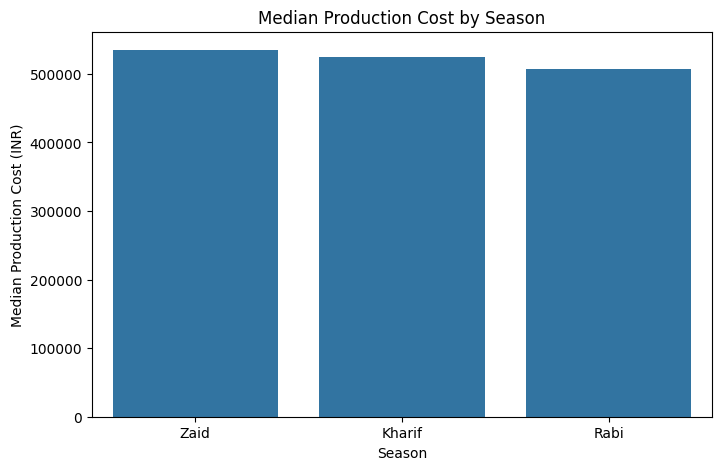

In [79]:
plt.figure(figsize = (8, 5))
cost_median = (data.groupby('Season')['Total_Cost_INR'].median().sort_values(ascending = False))
sns.barplot(x = cost_median.index, y = cost_median.values)
plt.title('Median Production Cost by Season')
plt.xlabel('Season')
plt.ylabel('Median Production Cost (INR)')
plt.show()

Production costs do not follow the same pattern as revenue. Zaid has the highest median production cost at ₹534,833 despite having the lowest median revenue. Kharif has a slightly lower median cost of ₹524,840 but generates substantially higher revenue. This difference between revenue and cost helps explain the much stronger profitability of Kharif compared with Zaid.

#### Profitability Across Crops

Crop-level profitability is examined to identify which crops generate stronger economic returns and which crops face comparatively lower profitability.

In [81]:
crop_profit = (data.groupby('Crop')['Profit_INR'].agg(Mean = 'mean', Median = 'median', Count = 'count').round(2).sort_values('Median', ascending = True))
crop_profit

,Mean,Median,Count
Crop,,,
Wheat,-123398.34,-76269.0,614
Rice,-102213.50,-58286.0,690
Maize,-83978.33,-42625.0,551
Pulses,-4238.05,2575.5,496
Groundnut,44858.12,36307.0,424
Cotton,124546.92,62092.5,508
Chilli,750878.34,536375.0,412
Sugarcane,817187.99,691166.0,305


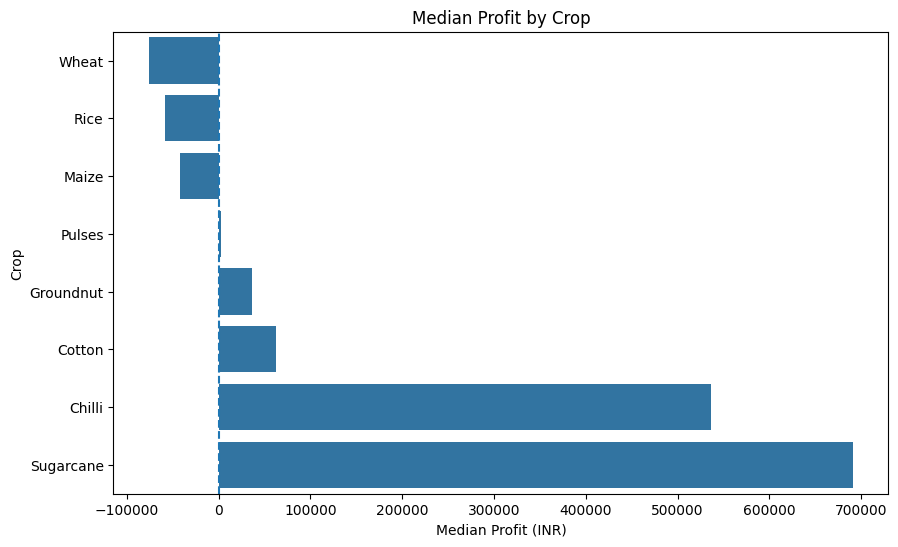

In [82]:
plt.figure(figsize = (10, 6))
sns.barplot(x = crop_profit['Median'], y = crop_profit.index)
plt.axvline(0, linestyle = '--')
plt.title('Median Profit by Crop')
plt.xlabel('Median Profit (INR)')
plt.ylabel('Crop')
plt.show()

Economic performance varies substantially across crops. Sugarcane records the highest median profit at ₹691,166, followed by Chilli at ₹536,375. Cotton and Groundnut also show positive median profits, while Maize, Rice and Wheat have negative median profits. This indicates that high agricultural productivity does not necessarily translate into the same level of economic return across all crops, as revenue and production costs also influence profitability.

#### Relationship Between Yield and Profit

Yield and profit are compared to examine whether higher agricultural productivity is associated with stronger economic returns.

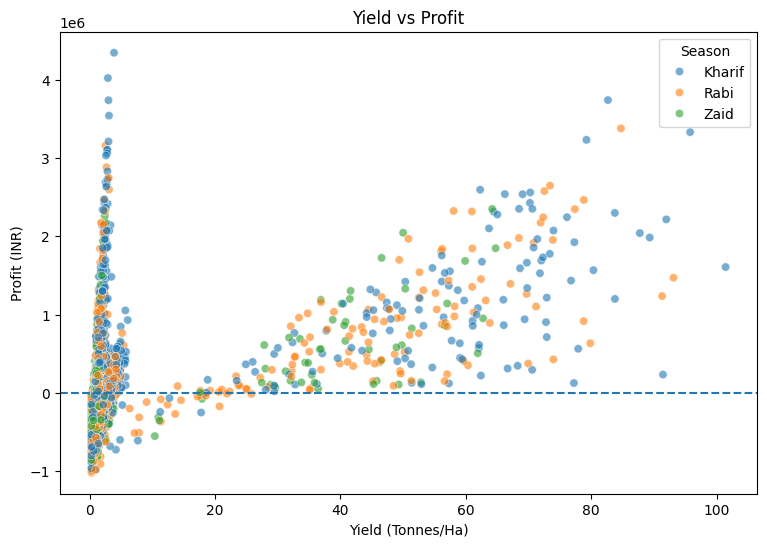

In [83]:
plt.figure(figsize = (9, 6))
sns.scatterplot(data = data, x = 'Yield_Tonnes_Ha', y = 'Profit_INR', hue = 'Season', alpha = 0.6)
plt.axhline(0, linestyle = '--')
plt.title('Yield vs Profit')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Profit (INR)')
plt.show()

In [84]:
yield_profit_corr = data[['Yield_Tonnes_Ha', 'Profit_INR']].corr().iloc[0, 1]
print(
    f"Correlation between Yield and Profit: "
    f"{yield_profit_corr:.3f}"
)

Correlation between Yield and Profit: 0.488


Yield and profit show a moderate positive relationship, with a correlation of approximately 0.49. This suggests that farms with higher yields tend to achieve higher profits, although the relationship is not strong enough to explain profitability on its own. Revenue, production costs, crop type and other farm-level factors also contribute to economic outcomes.

In [85]:
seasonal_summary = (data.groupby('Season').agg(
            Median_Yield = ('Yield_Tonnes_Ha', 'median'),
            Median_Revenue = ('Revenue_INR', 'median'),
            Median_Cost = ('Total_Cost_INR', 'median'),
            Median_Profit = ('Profit_INR', 'median'),
            Median_Water_Used = ('Water_Used_m3', 'median'),
            Median_Water_Efficiency = ('Water_Efficiency_t_per_1000m3', 'median')).round(2))
seasonal_summary

,Median_Yield,Median_Revenue,Median_Cost,Median_Profit,Median_Water_Used,Median_Water_Efficiency
Season,,,,,,
Kharif,1.94,520196.0,524840.0,38808.0,4469.0,3.28
Rabi,1.67,438156.0,506733.0,-3187.0,4292.0,2.74
Zaid,1.46,373700.5,534833.0,-62144.0,4805.0,2.30


### Conclusion

The analysis shows clear differences in agricultural performance across Kharif, Rabi and Zaid seasons. Kharif demonstrates the strongest overall performance, recording the highest median yield, water-use efficiency, revenue and profit, as well as the highest proportion of profitable farms. Zaid shows the weakest overall economic performance, with the lowest median yield, water-use efficiency, revenue and profit.

Environmental conditions also vary considerably across seasons. Kharif has the highest soil moisture, while Zaid has the lowest soil moisture and highest temperature. However, individual environmental variables such as rainfall and soil moisture show almost no linear relationship with yield. Similarly, individual farming factors such as seed quality and fertilizer usage do not show meaningful linear relationships with yield in this dataset.

Crop type shows a much stronger difference in agricultural performance. Sugarcane has substantially higher yield and profitability than the other crops, while several crops such as Wheat, Rice and Maize show negative median profits. These results highlight the importance of considering crop type when evaluating seasonal agricultural performance.

Irrigation analysis shows clear differences in resource use. Flood irrigation has the highest median water consumption and the lowest water-use efficiency, while Drip irrigation achieves the highest median yield overall and performs particularly well during Kharif and Rabi. Sprinkler irrigation records the highest median yield among irrigation methods during Zaid. This suggests that irrigation effectiveness varies according to seasonal conditions.

Economic analysis further shows that higher yield is generally associated with higher profit, although the relationship is only moderate. Therefore, agricultural profitability depends not only on productivity but also on revenue, production costs, crop choice and resource-management practices.

Overall, the findings suggest that effective seasonal agricultural planning should consider the combined effects of season, crop selection, irrigation strategy, resource efficiency and economic costs rather than relying on any single environmental or farming factor.

#### Data-Driven Recommendations

These should directly come from your findings rather than being generic farming advice.

**1. Prioritize seasonal planning**

Kharif demonstrates the strongest overall performance, so seasonal planning should take advantage of the conditions associated with Kharif while identifying ways to improve performance during Rabi and especially Zaid.

**2. Improve water management**

Flood irrigation consumes substantially more water while showing the lowest water-use efficiency. More efficient irrigation approaches such as Drip should be considered where appropriate, particularly given its relatively high median yield.

**3. Give greater attention to Zaid**

Zaid has:

lowest median yield
lowest water efficiency
lowest median revenue
lowest median profit
only 35.52% profitable farms

Therefore:

Zaid should be treated as the priority season for improving resource efficiency and economic performance.

**4. Consider crop economics, not only yield**

Sugarcane has extremely high yield and profitability, but we shouldn't simply recommend planting sugarcane everywhere.

Instead:

Crop selection should consider both expected productivity and economic returns, because yield and profitability vary substantially between crops.

**5. Avoid assuming that more inputs automatically produce higher yield**

Our correlations showed essentially no linear relationship between yield and:

rainfall
soil moisture
fertilizer
seed quality
disease/pest risk

Therefore:

Agricultural planning should avoid relying on a single input as the primary explanation for yield performance. A combination of crop, season, irrigation and farm-management factors should be considered.

**6. Focus on profitability, not just production**

This is perhaps the most important recommendation:

Farm performance should be evaluated using both productivity and economic indicators. Higher yield can contribute to higher profit, but revenue and production costs determine whether higher production actually results in a financially sustainable outcome.